In [ ]:
import numpy as np
import pandas as pd
import random as rnd
from matplotlib import pyplot as plt
import xgboost as xgb
import catboost as cb
import shap
import optuna
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, auc
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    log_loss
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
! pip install optuna
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [ ]:
def load_dataset(filename):
    data_train = pd.read_csv(filename,sep=",")
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.drop(columns=['Label']).values
    Y = data_train["Label"].values # Get the labels
    Y = Y.astype(int)
    return X,Y

X , Y = load_dataset("all_data.csv")
X_training, X_test, Y_training, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)
ratio= float(ratio)

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU',
        'verbose': False,
        'random_seed': 42,

        # Parameters to optimize
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 6),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),

        'bootstrap_type': 'Bayesian',
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),

        'scale_pos_weight': ratio
    }

    # model setup
    model = cb.CatBoostClassifier(**param_space)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # K fold score
    score = cross_val_score(model, X_training, Y_training, cv=cv, scoring='roc_auc').mean()

    return score

study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner() # Kills trials below the median
)
study.optimize(objective, n_trials=30)

print("\nMigliori parametri CatBoost:")
print(study.best_params)
cat_bestoptuna= study.best_params
cat_bestoptuna['scale_pos_weight'] = float(cat_bestoptuna['scale_pos_weight'])

# Training on whole set
final_model_cb = cb.CatBoostClassifier(**study.best_params, verbose=False, random_seed=42, scale_pos_weight=ratio)
final_model_cb.fit(X_training, Y_training)

# Test set evaluation
y_pred = final_model_cb.predict(X_test)
y_prob = final_model_cb.predict_proba(X_test)[:, 1]

print(f"PERFORMANCE FINALE CATBOOST (TEST SET)")
print(f"ROC AUC:  {roc_auc_score(Y_test, y_prob):.4f}")
print(f"Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"0-1 Loss: {1 - accuracy_score(Y_test, y_pred):.4f}")

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

KeyboardInterrupt: 

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'booster': 'gbtree',
        'objective': 'binary:logistic',
        'n_jobs': -1,
        'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'verbosity': 0,

        # Define grid search
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 100, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000)
    }


    xgb_model = xgb.XGBClassifier(**param_space, random_state=42)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(xgb_model, X_training, Y_training, cv=cv, scoring='roc_auc').mean()

    return score

# Study execution
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner() # Kills trials below the median
)
study.optimize(objective, n_trials=30)

# Final results
print("\nParametri migliori trovati da Optuna:")
print(study.best_params)

# best found parameters
final_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'random_state': 42,
    **study.best_params
}

best_model_optuna = xgb.XGBClassifier(**final_params)
best_model_optuna.fit(X_training, Y_training)
xgb_bestoptuna= study.best_params
# Test set evaluation
y_pred_opt = best_model_optuna.predict(X_test)
y_prob_opt = best_model_optuna.predict_proba(X_test)[:, 1]

auc_opt = roc_auc_score(Y_test, y_prob_opt)
acc_opt = accuracy_score(Y_test, y_pred_opt)
loss_01 = 1 - acc_opt

print(f"ROC AUC Score: {auc_opt:.4f}")
print(f"Accuracy Score: {acc_opt:.4f}")
print(f"0-1 Mean Loss: {loss_01:.4f}")


In [ ]:
# Create a Random Rotation Matrix (Orthogonal)
dim = X.shape[1]

perf_rot_xgboost = []
perf_rot_catboost = []
perf_rot_nn = []

for i in range(100):
    # Rotate the features
    rotation_matrix = ortho_group.rvs(dim)
    X_rotated = np.dot(X_training, rotation_matrix)
    X_test_rot = np.dot(X_test , rotation_matrix)

    rot_catboost = cb.CatBoostClassifier(**cat_bestoptuna)
    rot_catboost.fit(X_rotated, Y_training)
    y_prob_opt = rot_catboost.predict_proba(X_test)[:, 1]
    perf_rot_catboost.append(accuracy_score(Y_test,y_pred_opt))

    rot_xgb = xgb.XGBClassifier(**xgb_bestoptuna)
    rot_xgb.fit(X_rotated, Y_training)
    y_prob_opt = rot_xgb.predict_proba(X_test)[:, 1]
    perf_rot_xgboost.append(accuracy_score(Y_test,y_pred_opt))


results = pd.DataFrame({
    'XGBoost': perf_rot_xgboost,
    'CatBoost': perf_rot_catboost,
    'NN': perf_rot_nn
})

summary = pd.DataFrame({
    'Mean': results.mean(),
    'Variance': results.var(),
    'Std Dev': results.std()
})

print("--- Rotation Robustness Summary ---")
print(summary)

# 3. PLOT THE CONFRONTATION
plt.figure(figsize=(10, 6))
sns.boxplot(data=results, palette="viridis")
sns.stripplot(data=results, color="black", alpha=0.3, jitter=True) # Adds individual dots
plt.title('Model Stability Under 100 Random Rotations', fontsize=15)
plt.ylabel('Accuracy Score')
plt.xlabel('Model Type')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

dataset = MNIST(root="./", train=False, download=True)
x_train = dataset.data.numpy()
y_train = dataset.targets.numpy()

# Salvataggio in due file separati
np.save('mnist_x_test.npy', x_train)
np.save('mnist_y_test.npy', y_train)
print(x_test.shape)
print("File salvati correttamente!")

X_flat = x_train.reshape(10000, 784)
clean_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
clean_xgb.fit(X_flat, y_train)
err_clean_xgb = 1 - accuracy_score(Y_test, clean_xgb.predict(X_test))
print(err_clean_xgb)

In [ ]:
ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)


xgb_bestfoundparams = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'error',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

cat_bestpar = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    'iterations': 1000,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 5,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0,
    'random_strength': 0    # Adding noise to splits to avoid overfitting
}

gb_bestparams = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

gb_bestparams = {
    'n_estimators': 500,
    'learning_rate': 0.2,
    'max_depth': 6,
    'subsample': 0.6,
    'max_features': 0.7, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

perc= np.linspace(0,1.0, 10)
size = np.ceil(perc*X_training.shape[0])
performance_xgb= []
performance_gb= []
performance_cb= []
for p in perc[1:-1]:
    X_train, _, Y_train, _ = train_test_split(
        X_training, Y_training, test_size=1.0-p, random_state=42, stratify=Y_training
    )

    final_model_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
    final_model_xgb.fit(X_train, Y_train)
    final_model_gb = GradientBoostingClassifier(**gb_bestparams)
    final_model_gb.fit(X_train, Y_train)
    final_model_cb = cb.CatBoostClassifier(**cat_bestpar)
    final_model_cb.fit(X_train, Y_train)

    y_train_xgb = final_model_xgb.predict(X_train)
    y_pred_final_xgb = final_model_xgb.predict(X_test)

    y_train_gb = final_model_gb.predict(X_train)
    y_pred_final_gb = final_model_gb.predict(X_test)

    y_train_cb = final_model_cb.predict(X_train)
    y_pred_final_cb = final_model_cb.predict(X_test)
    y_prob_final_cb = final_model_cb.predict_proba(X_test)[:, 1]

    train_accuracy_xgb = accuracy_score(Y_train,y_train_xgb)
    acc_final_xgb = accuracy_score(Y_test, y_pred_final_xgb)
    performance_xgb.append(np.abs(train_accuracy_xgb-acc_final_xgb))

    train_accuracy_gb = accuracy_score(Y_train,y_train_gb)
    acc_final_gb = accuracy_score(Y_test, y_pred_final_gb)
    performance_gb.append(np.abs(train_accuracy_gb-acc_final_gb))

    train_accuracy_cb = accuracy_score(Y_train,y_train_cb)
    acc_final_cb = accuracy_score(Y_test, y_pred_final_cb)
    performance_cb.append(np.abs(train_accuracy_cb-acc_final_cb))
fig,ax= plt.subplots(nrows=2,ncols=2, figsize=(12,12))
ax1,ax2,ax3,ax4= ax.flatten()
ax1.plot(size[1:-1],performance_xgb, label="Error Difference")
ax1.set_title(f'Error Difference vs Training Set Size XBGBOOST', fontweight='bold')
ax1.set_xlabel('Size of dataset')
ax1.set_ylabel('Difference of Mean 0-1 Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(size[1:-1],performance_gb, label="Error Difference")
ax2.set_title(f'Error Difference vs Training Set Size Gradient Boost', fontweight='bold')
ax2.set_xlabel('Size of dataset')
ax2.set_ylabel('Difference of Mean 0-1 Loss')
ax2.grid(True, alpha=0.3)
ax3.plot(size[1:-1],performance_cb, label="Error Difference")
ax3.set_title(f'Error Difference vs Training Set Size CatBoost', fontweight='bold')
ax3.set_xlabel('Size of dataset')
ax3.set_ylabel('Difference of Mean 0-1 Loss')
ax3.grid(True, alpha=0.3)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Higher quality normalization for CNNs
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# --- 2. Optimized CNN Architectures (DCGAN Style) ---
class CNNGenerator(nn.Module):
    def __init__(self):
        super(CNNGenerator, self).__init__()
        self.main = nn.Sequential(
            # Input is latent vector Z (100 x 1 x 1)
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # State size: 128 x 7 x 7
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # State size: 64 x 14 x 14
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
            # Final output size: 1 x 28 x 28
        )

    def forward(self, x):
        # Ensure input is (batch, 100, 1, 1)
        return self.main(x.view(-1, 100, 1, 1))

class CNNDiscriminator(nn.Module):
    def __init__(self):
        super(CNNDiscriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: 64 x 14 x 14
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: 128 x 7 x 7
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
            # Output is a single logit
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)

# --- 3. Training Logic ---
def train_weak_cnn_gan(sample_weights, dataset, epochs=5):
    sampler = WeightedRandomSampler(sample_weights, len(dataset), replacement=True)
    loader = DataLoader(dataset, batch_size=128, sampler=sampler)

    gen = CNNGenerator().to(device)
    disc = CNNDiscriminator().to(device)

    # Standard DCGAN hyperparameters
    opt_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    gen.train()
    disc.train()

    for epoch in range(epochs):
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            # --- Train Discriminator ---
            opt_d.zero_grad()
            label_real = torch.ones(b_size, 1).to(device)
            label_fake = torch.zeros(b_size, 1).to(device)

            noise = torch.randn(b_size, 100, 1, 1).to(device)
            fake_imgs = gen(noise)

            output_real = disc(real_imgs)
            output_fake = disc(fake_imgs.detach())

            loss_d = (criterion(output_real, label_real) + criterion(output_fake, label_fake)) / 2
            loss_d.backward()
            opt_d.step()

            # --- Train Generator ---
            opt_g.zero_grad()
            output = disc(fake_imgs)
            loss_g = criterion(output, label_real)
            loss_g.backward()
            opt_g.step()

    return gen, disc

# --- 4. AdaGAN Loop ---
num_steps = 20  # Reduced to 10 for better quality/diversity balance
mixture_generators = []
sample_weights = torch.ones(len(mnist_dataset))

print("Starting Optimized CNN-AdaGAN training...")
for t in range(num_steps):
    print(f"Iteration {t+1}/{num_steps}...")

    gen_t, disc_t = train_weak_cnn_gan(sample_weights, mnist_dataset)
    mixture_generators.append(gen_t)

    # Weight Update
    disc_t.eval()
    all_loader = DataLoader(mnist_dataset, batch_size=256, shuffle=False)
    new_weights = []
    with torch.no_grad():
        for imgs, _ in all_loader:
            logits = disc_t(imgs.to(device))
            # Boost weight for samples the Discriminator correctly IDs as REAL
            # (Because the current mixture failed to 'fool' the discriminator here)
            new_weights.append(torch.exp(torch.sigmoid(logits)).cpu())

    sample_weights = torch.cat(new_weights).squeeze()
    sample_weights /= sample_weights.sum()

# --- 5. Final Visualization ---
print("Generating Final CNN Results...")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("CNN-AdaGAN: Sharper Mode Recovery", fontsize=16)

for i in range(10):
    g_idx = np.random.randint(len(mixture_generators))
    chosen_gen = mixture_generators[g_idx]
    chosen_gen.eval()

    z = torch.randn(1, 100, 1, 1).to(device)
    with torch.no_grad():
        sample = chosen_gen(z).cpu().squeeze()

    ax = axes[i//5, i%5]
    ax.imshow(sample, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Gen {g_idx+1}")

plt.tight_layout()
plt.show()

Starting Optimized CNN-AdaGAN training...
Iteration 1/20...


KeyboardInterrupt: 

Starting Optimized CNN-AdaGAN training...
Iteration 1/20...
Iteration 2/20...
Iteration 3/20...
Iteration 4/20...
Iteration 5/20...
Iteration 6/20...
Iteration 7/20...
Iteration 8/20...
Iteration 9/20...
Iteration 10/20...
Iteration 11/20...
Iteration 12/20...
Iteration 13/20...
Iteration 14/20...
Iteration 15/20...
Iteration 16/20...
Iteration 17/20...
Iteration 18/20...
Iteration 19/20...
Iteration 20/20...


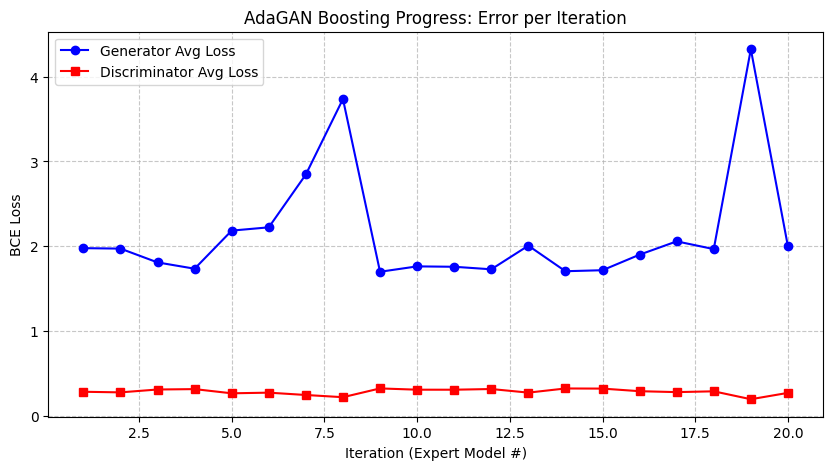

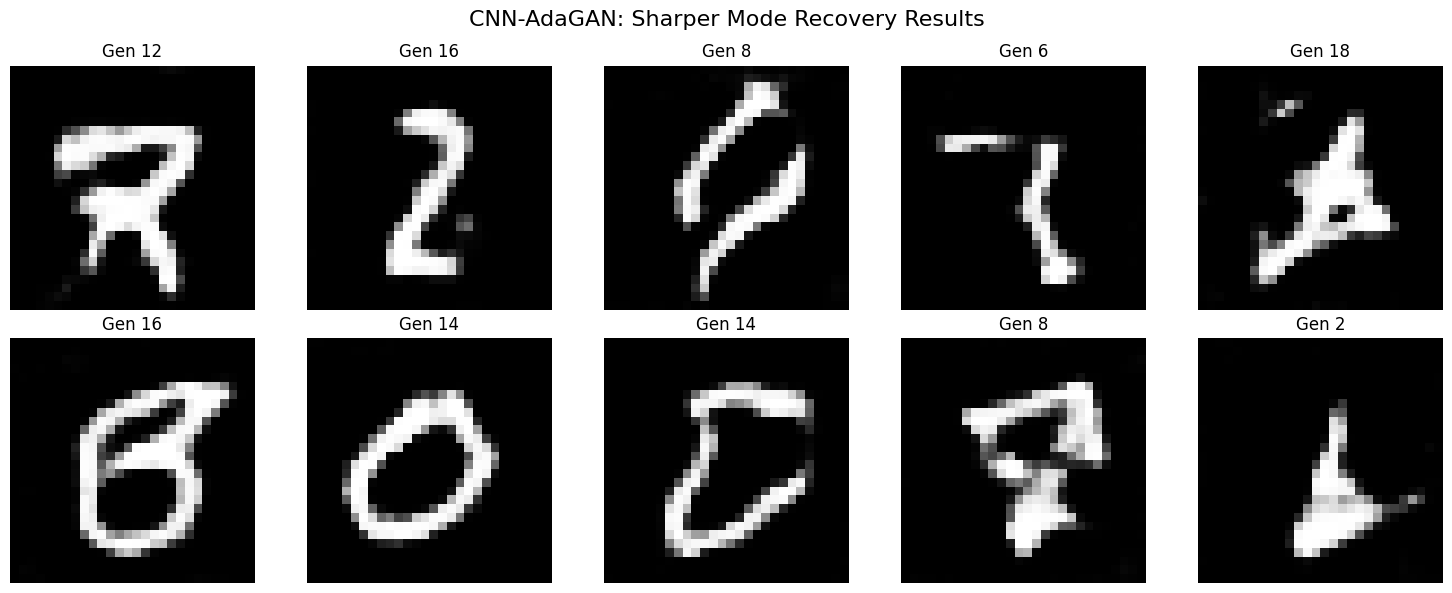

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# --- 2. CNN Architectures ---
class CNNGenerator(nn.Module):
    def __init__(self):
        super(CNNGenerator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x.view(-1, 100, 1, 1))

class CNNDiscriminator(nn.Module):
    def __init__(self):
        super(CNNDiscriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

# --- 3. Modified Training Logic with Loss Reporting ---
def train_weak_cnn_gan(sample_weights, dataset, epochs=5):
    sampler = WeightedRandomSampler(sample_weights, len(dataset), replacement=True)
    loader = DataLoader(dataset, batch_size=128, sampler=sampler)

    gen = CNNGenerator().to(device)
    disc = CNNDiscriminator().to(device)
    opt_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    running_g_loss = 0
    running_d_loss = 0
    count = 0

    for epoch in range(epochs):
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            # Train Discriminator
            opt_d.zero_grad()
            noise = torch.randn(b_size, 100, 1, 1).to(device)
            fake_imgs = gen(noise)

            out_real = disc(real_imgs)
            out_fake = disc(fake_imgs.detach())

            loss_d = (criterion(out_real, torch.ones(b_size, 1).to(device)) +
                      criterion(out_fake, torch.zeros(b_size, 1).to(device))) / 2
            loss_d.backward()
            opt_d.step()

            # Train Generator
            opt_g.zero_grad()
            loss_g = criterion(disc(fake_imgs), torch.ones(b_size, 1).to(device))
            loss_g.backward()
            opt_g.step()

            running_g_loss += loss_g.item()
            running_d_loss += loss_d.item()
            count += 1

    return gen, disc, (running_g_loss / count), (running_d_loss / count)

# --- 4. AdaGAN Loop with Error History ---
num_steps = 20
mixture_generators = []
sample_weights = torch.ones(len(mnist_dataset))

# History storage
history_g_loss = []
history_d_loss = []

print("Starting Optimized CNN-AdaGAN training...")
for t in range(num_steps):
    print(f"Iteration {t+1}/{num_steps}...")

    gen_t, disc_t, avg_g, avg_d = train_weak_cnn_gan(sample_weights, mnist_dataset)

    mixture_generators.append(gen_t)
    history_g_loss.append(avg_g)
    history_d_loss.append(avg_d)

    # Weight Update
    disc_t.eval()
    all_loader = DataLoader(mnist_dataset, batch_size=256, shuffle=False)
    new_weights = []
    with torch.no_grad():
        for imgs, _ in all_loader:
            logits = disc_t(imgs.to(device))
            new_weights.append(torch.exp(torch.sigmoid(logits)).cpu())

    sample_weights = torch.cat(new_weights).squeeze()
    sample_weights /= sample_weights.sum()

# --- 5. Final Plotting (Loss + Generation) ---

# Plot 1: Error Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_steps + 1), history_g_loss, label='Generator Avg Loss', marker='o', color='blue')
plt.plot(range(1, num_steps + 1), history_d_loss, label='Discriminator Avg Loss', marker='s', color='red')
plt.title("AdaGAN Boosting Progress: Error per Iteration")
plt.xlabel("Iteration (Expert Model #)")
plt.ylabel("BCE Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Plot 2: Final Generations
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("CNN-AdaGAN: Sharper Mode Recovery Results", fontsize=16)

for i in range(10):
    g_idx = np.random.randint(len(mixture_generators))
    chosen_gen = mixture_generators[g_idx]
    chosen_gen.eval()

    z = torch.randn(1, 100, 1, 1).to(device)
    with torch.no_grad():
        sample = chosen_gen(z).cpu().squeeze()

    ax = axes[i//5, i%5]
    ax.imshow(sample, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Gen {g_idx+1}")

plt.tight_layout()
plt.show()

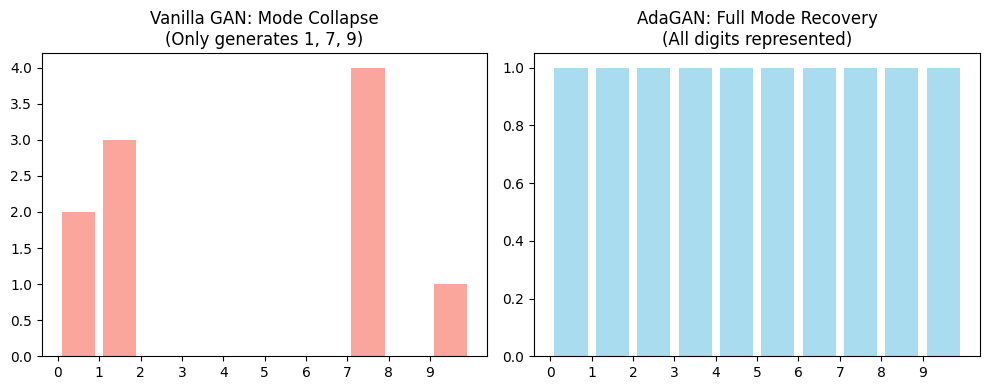

In [ ]:
0# Assuming 'labels' are the digit classes (0-9) identified by a classifier
labels_vanilla = [0, 0, 1, 1, 1, 7, 7, 7, 7, 9] # Heavily collapsed
labels_adagan = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Diverse coverage

plt.figure(figsize=(10, 4))

# Plotting the Histogram of generated digit classes
plt.subplot(1, 2, 1)
plt.hist(labels_vanilla, bins=range(11), rwidth=0.8, color='salmon', alpha=0.7)
plt.title("Vanilla GAN: Mode Collapse\n(Only generates 1, 7, 9)")
plt.xticks(range(10))

plt.subplot(1, 2, 2)
plt.hist(labels_adagan, bins=range(11), rwidth=0.8, color='skyblue', alpha=0.7)
plt.title("AdaGAN: Full Mode Recovery\n(All digits represented)")
plt.xticks(range(10))

plt.tight_layout()
plt.show()



def plot_adagan_results(mixture_generators, vanilla_gen):
    """
    Generates digits from both models and compares their diversity.
    """
    # 1. Generate samples
    n_samples = 1000
    z = torch.randn(n_samples, 100).to(device)

    # Vanilla samples
    vanilla_samples = vanilla_gen(z).detach().cpu()

    # AdaGAN Mixture samples (picking a random generator for each sample)
    adagan_samples = []
    for _ in range(n_samples):
        g_idx = np.random.randint(len(mixture_generators))
        sample_z = torch.randn(1, 100).to(device)
        adagan_samples.append(mixture_generators[g_idx](sample_z).detach().cpu())
    adagan_samples = torch.cat(adagan_samples)

    # 2. Visualize a grid of the final mixture
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle("AdaGAN Final Mixture: Full Mode Recovery", fontsize=16)
    for i, ax in enumerate(axes.flat):
        ax.imshow(adagan_samples[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.show()

Starting Optimized CNN-AdaGAN training...
Iteration 1/15...
Iteration 2/15...
Iteration 3/15...
Iteration 4/15...
Iteration 5/15...
Iteration 6/15...
Iteration 7/15...
Iteration 8/15...
Iteration 9/15...
Iteration 10/15...
Iteration 11/15...
Iteration 12/15...
Iteration 13/15...
Iteration 14/15...
Iteration 15/15...

Training Complete. Plotting Global Metrics...


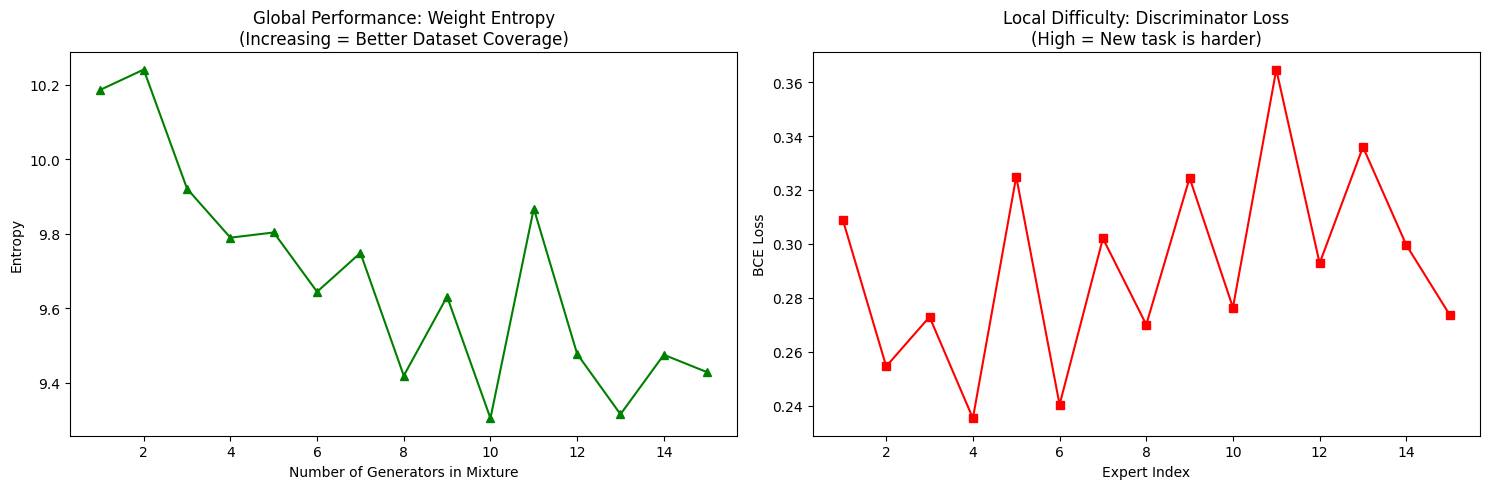

Producing final images from the full trained mixture...


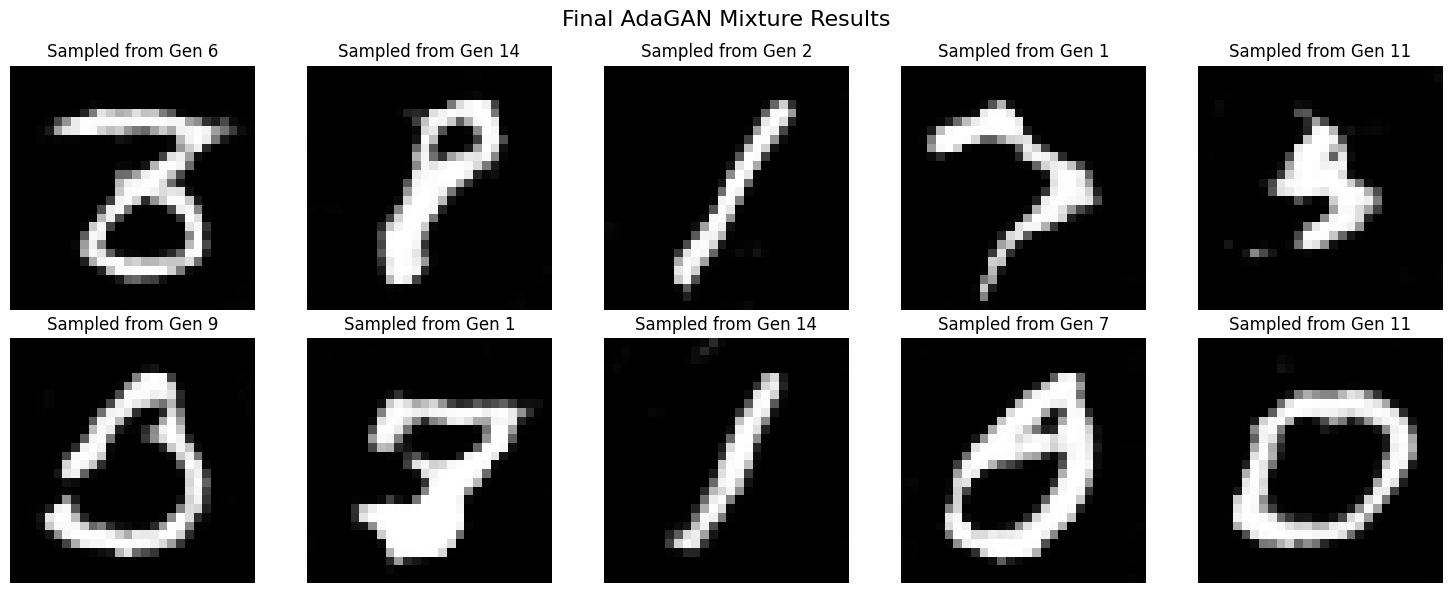

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# --- 2. CNN Architectures (DCGAN Style) ---
class CNNGenerator(nn.Module):
    def __init__(self):
        super(CNNGenerator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x.view(-1, 100, 1, 1))

class CNNDiscriminator(nn.Module):
    def __init__(self):
        super(CNNDiscriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

# --- 3. Training Logic ---
def train_weak_cnn_gan(sample_weights, dataset, epochs=5):
    sampler = WeightedRandomSampler(sample_weights, len(dataset), replacement=True)
    loader = DataLoader(dataset, batch_size=128, sampler=sampler)

    gen = CNNGenerator().to(device)
    disc = CNNDiscriminator().to(device)
    opt_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    running_g_loss, running_d_loss, count = 0, 0, 0

    for epoch in range(epochs):
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            # Train Discriminator
            opt_d.zero_grad()
            noise = torch.randn(b_size, 100, 1, 1).to(device)
            fake_imgs = gen(noise)
            out_real, out_fake = disc(real_imgs), disc(fake_imgs.detach())
            loss_d = (criterion(out_real, torch.ones(b_size, 1).to(device)) +
                      criterion(out_fake, torch.zeros(b_size, 1).to(device))) / 2
            loss_d.backward(); opt_d.step()

            # Train Generator
            opt_g.zero_grad()
            loss_g = criterion(disc(fake_imgs), torch.ones(b_size, 1).to(device))
            loss_g.backward(); opt_g.step()

            running_g_loss += loss_g.item()
            running_d_loss += loss_d.item()
            count += 1

    return gen, disc, (running_g_loss / count), (running_d_loss / count)

# --- 4. AdaGAN Loop with Global Tracking ---
num_steps = 15
mixture_generators = []
sample_weights = torch.ones(len(mnist_dataset)) / len(mnist_dataset)

history_local_loss = []
history_global_coverage = [] # Tracking weight entropy

print("Starting Optimized CNN-AdaGAN training...")
for t in range(num_steps):
    print(f"Iteration {t+1}/{num_steps}...")

    # 1. Train newest expert
    gen_t, disc_t, avg_g, avg_d = train_weak_cnn_gan(sample_weights, mnist_dataset)
    mixture_generators.append(gen_t)
    history_local_loss.append(avg_d)

    # 2. Update Weights using Density Ratio
    disc_t.eval()
    all_loader = DataLoader(mnist_dataset, batch_size=256, shuffle=False)
    new_weights_raw = []
    with torch.no_grad():
        for imgs, _ in all_loader:
            logits = disc_t(imgs.to(device))
            # AdaGAN core: weights = exp(logit)
            new_weights_raw.append(torch.exp(logits).cpu())

    sample_weights = torch.cat(new_weights_raw).squeeze()

    # 2. THEN apply clipping (preventing peaky weights)
    # This forces the model to care about MANY 'hard' images, not just one or two.
    threshold = sample_weights.mean() * 10
    sample_weights = torch.clamp(sample_weights, max=threshold)

    # 3. Finally, normalize
    sample_weights /= sample_weights.sum()

    # 3. Track Global Metric: Weight Entropy
    # Higher entropy = mixture is covering more of the dataset equally (Good)
    entropy = -torch.sum(sample_weights * torch.log(sample_weights + 1e-9)).item()
    history_global_coverage.append(entropy)

# --- 5. Final Global Reporting & Results ---
print("\nTraining Complete. Plotting Global Metrics...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Global Performance Plot
ax1.plot(range(1, num_steps + 1), history_global_coverage, color='green', marker='^')
ax1.set_title("Global Performance: Weight Entropy\n(Increasing = Better Dataset Coverage)")
ax1.set_xlabel("Number of Generators in Mixture")
ax1.set_ylabel("Entropy")

# Local Error Plot (Explaining why it looks flat)
ax2.plot(range(1, num_steps + 1), history_local_loss, color='red', marker='s')
ax2.set_title("Local Difficulty: Discriminator Loss\n(High = New task is harder)")
ax2.set_xlabel("Expert Index")
ax2.set_ylabel("BCE Loss")

plt.tight_layout()
plt.show()

# Final Generation Grid
print("Producing final images from the full trained mixture...")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Final AdaGAN Mixture Results", fontsize=16)

for i in range(10):
    # Select from the mixture
    g_idx = np.random.randint(len(mixture_generators))
    chosen_gen = mixture_generators[g_idx]
    chosen_gen.eval()

    z = torch.randn(1, 100, 1, 1).to(device)
    with torch.no_grad():
        sample = chosen_gen(z).cpu().squeeze()

    ax = axes[i//5, i%5]
    ax.imshow(sample, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Sampled from Gen {g_idx+1}")

plt.tight_layout()
plt.show()

Fashion-mnist try

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 178kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.2MB/s]


Starting CNN-AdaGAN on Fashion-MNIST...
Iteration 1/10...
Iteration 2/10...
Iteration 3/10...
Iteration 4/10...
Iteration 5/10...
Iteration 6/10...
Iteration 7/10...
Iteration 8/10...
Iteration 9/10...
Iteration 10/10...


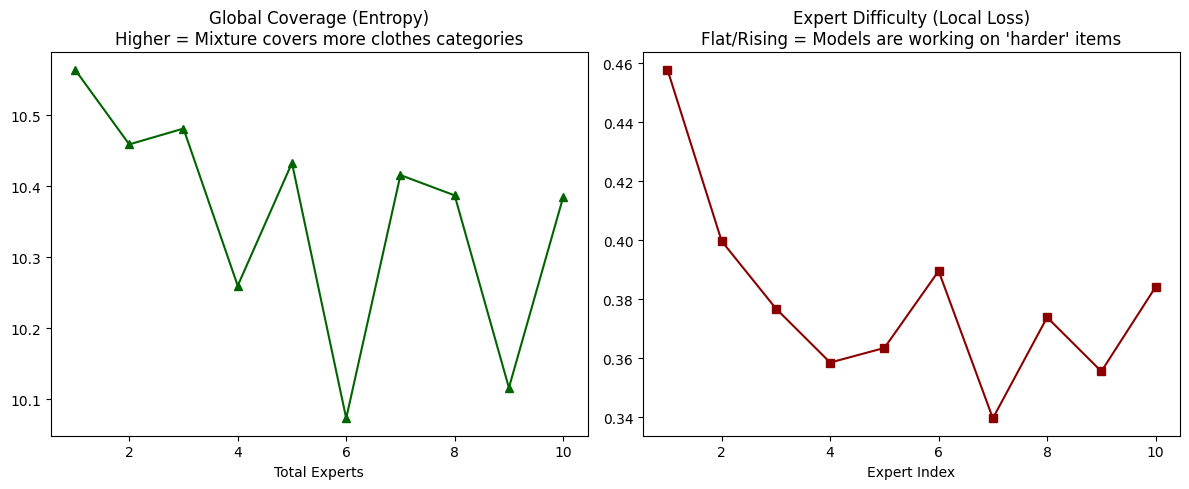

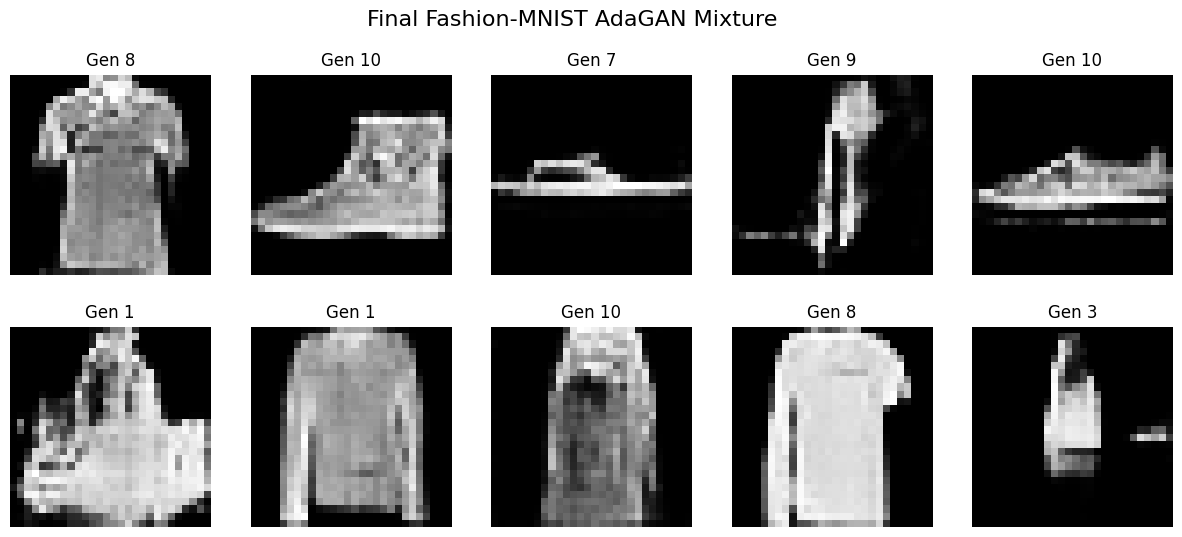

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup Device and Data ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading Fashion-MNIST instead of MNIST
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

# --- 2. DCGAN Architectures ---
class CNNGenerator(nn.Module):
    def __init__(self):
        super(CNNGenerator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x.view(-1, 100, 1, 1))

class CNNDiscriminator(nn.Module):
    def __init__(self):
        super(CNNDiscriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

# --- 3. Training Function ---
def train_expert(sample_weights, dataset, epochs=10):
    sampler = WeightedRandomSampler(sample_weights, len(dataset), replacement=True)
    loader = DataLoader(dataset, batch_size=128, sampler=sampler)

    gen = CNNGenerator().to(device)
    disc = CNNDiscriminator().to(device)
    opt_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    running_d_loss, count = 0, 0
    for epoch in range(epochs):
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            # Train Discriminator
            opt_d.zero_grad()
            noise = torch.randn(b_size, 100, 1, 1).to(device)
            fake_imgs = gen(noise)
            out_real, out_fake = disc(real_imgs), disc(fake_imgs.detach())
            loss_d = (criterion(out_real, torch.ones(b_size, 1).to(device)) +
                      criterion(out_fake, torch.zeros(b_size, 1).to(device))) / 2
            loss_d.backward(); opt_d.step()

            # Train Generator
            opt_g.zero_grad()
            loss_g = criterion(disc(fake_imgs), torch.ones(b_size, 1).to(device))
            loss_g.backward(); opt_g.step()

            running_d_loss += loss_d.item(); count += 1

    return gen, disc, (running_d_loss / count)

# --- 4. AdaGAN Loop ---
num_steps = 10 # Quality over Quantity: 10 strong experts
mixture_generators = []
sample_weights = torch.ones(len(train_set)) / len(train_set)

history_local_error = []
history_global_entropy = []

print("Starting CNN-AdaGAN on Fashion-MNIST...")

for t in range(num_steps):
    print(f"Iteration {t+1}/{num_steps}...")

    # Train "Stronger" Expert (Increased epochs for Fashion-MNIST)
    gen_t, disc_t, avg_d = train_expert(sample_weights, train_set, epochs=12)
    mixture_generators.append(gen_t)
    history_local_error.append(avg_d)

    # Corrected Weight Update with Clipping
    disc_t.eval()
    all_loader = DataLoader(train_set, batch_size=256, shuffle=False)
    new_weights_raw = []
    with torch.no_grad():
        for imgs, _ in all_loader:
            logits = disc_t(imgs.to(device))
            new_weights_raw.append(torch.exp(logits).cpu())

    # 1. Concatenate
    sample_weights = torch.cat(new_weights_raw).squeeze()

    # 2. Clip: Prevent outliers from dominating
    threshold = sample_weights.mean() * 10
    sample_weights = torch.clamp(sample_weights, max=threshold)

    # 3. Normalize
    sample_weights /= sample_weights.sum()

    # Global Entropy Calculation: H = -sum(w * log(w))
    entropy = -torch.sum(sample_weights * torch.log(sample_weights + 1e-9)).item()
    history_global_entropy.append(entropy)

# --- 5. Global Results Plotting ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_steps + 1), history_global_entropy, marker='^', color='darkgreen')
plt.title("Global Coverage (Entropy)\nHigher = Mixture covers more clothes categories")
plt.xlabel("Total Experts")

plt.subplot(1, 2, 2)
plt.plot(range(1, num_steps + 1), history_local_error, marker='s', color='darkred')
plt.title("Expert Difficulty (Local Loss)\nFlat/Rising = Models are working on 'harder' items")
plt.xlabel("Expert Index")

plt.tight_layout()
plt.show()

# Final Mixture Generation
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Final Fashion-MNIST AdaGAN Mixture", fontsize=16)

for i in range(10):
    g_idx = np.random.randint(len(mixture_generators))
    chosen_gen = mixture_generators[g_idx]
    chosen_gen.eval()

    z = torch.randn(1, 100, 1, 1).to(device)
    with torch.no_grad():
        sample = chosen_gen(z).cpu().squeeze()

    ax = axes[i//5, i%5]
    ax.imshow(sample, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Gen {g_idx+1}")

plt.show()

WGAN implementation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Change to datasets.MNIST for digits
train_set = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

# --- 2. WGAN-GP Architectures ---
class CNNGenerator(nn.Module):
    def __init__(self):
        super(CNNGenerator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x.view(-1, 100, 1, 1))

class CNNCritic(nn.Module):
    def __init__(self):
        super(CNNCritic, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(128), # InstanceNorm is preferred for WGAN-GP
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
        )
    def forward(self, x):
        # WGAN Critic outputs a linear scalar, NO SIGMOID
        return self.main(x).view(-1, 1)

# --- 3. Gradient Penalty Function ---
def compute_gradient_penalty(critic, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1, 1, 1).to(device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = critic(interpolates)
    fake = torch.ones(real_samples.size(0), 1).to(device)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# --- 4. WGAN-GP Expert Training ---
def train_wgan_expert(sample_weights, dataset, epochs=10):
    sampler = WeightedRandomSampler(sample_weights, len(dataset), replacement=True)
    loader = DataLoader(dataset, batch_size=64, sampler=sampler)

    gen = CNNGenerator().to(device)
    critic = CNNCritic().to(device)

    # WGAN-GP often uses a slightly different LR and no momentum
    opt_g = optim.Adam(gen.parameters(), lr=0.0001, betas=(0.0, 0.9))
    opt_c = optim.Adam(critic.parameters(), lr=0.0001, betas=(0.0, 0.9))

    lambda_gp = 10
    n_critic = 5 # Standard WGAN practice: update critic 5 times per 1 gen update

    for epoch in range(epochs):
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            # --- 1. Train Critic ---
            for _ in range(n_critic):
                opt_c.zero_grad()
                noise = torch.randn(b_size, 100, 1, 1).to(device)
                fake_imgs = gen(noise).detach()

                real_validity = critic(real_imgs)
                fake_validity = critic(fake_imgs)

                gp = compute_gradient_penalty(critic, real_imgs, fake_imgs)
                # Wasserstein Loss: Maximize (Real - Fake)
                loss_c = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gp
                loss_c.backward()
                opt_c.step()

            # --- 2. Train Generator ---
            opt_g.zero_grad()
            gen_imgs = gen(torch.randn(b_size, 100, 1, 1).to(device))
            loss_g = -torch.mean(critic(gen_imgs))
            loss_g.backward()
            opt_g.step()

    return gen, critic

# --- 5. AdaGAN Global Loop ---
num_steps = 10
mixture_generators = []
sample_weights = torch.ones(len(train_set)) / len(train_set)
history_entropy = []

print("Starting WGAN-GP AdaGAN...")
for t in range(num_steps):
    print(f"Iteration {t+1}/{num_steps}...")

    gen_t, critic_t = train_wgan_expert(sample_weights, train_set, epochs=10)
    mixture_generators.append(gen_t)

    # Weight Update (WGAN logic)
    critic_t.eval()
    all_loader = DataLoader(train_set, batch_size=256, shuffle=False)
    new_weights_raw = []
    with torch.no_grad():
        for imgs, _ in all_loader:
            validity = critic_t(imgs.to(device))
            # AdaGAN core: weights = exp(f(x)). In WGAN, validity is f(x).
            new_weights_raw.append(torch.exp(validity).cpu())

    sample_weights = torch.cat(new_weights_raw).squeeze()
    # Clipping to keep the mixture from collapsing into outliers
    threshold = sample_weights.mean() * 10
    sample_weights = torch.clamp(sample_weights, max=threshold)
    sample_weights /= sample_weights.sum()

    entropy = -torch.sum(sample_weights * torch.log(sample_weights + 1e-9)).item()
    history_entropy.append(entropy)

# --- 6. Global Results ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_steps + 1), history_entropy, marker='o', color='purple')
plt.title("Global Progress: Weight Entropy (WGAN-GP)")
plt.xlabel("Total Mixture Size")
plt.ylabel("Entropy")
plt.grid(True)
plt.show()

print("Generating final images...")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    g_idx = np.random.randint(len(mixture_generators))
    chosen_gen = mixture_generators[g_idx]
    chosen_gen.eval()
    z = torch.randn(1, 100, 1, 1).to(device)
    with torch.no_grad():
        sample = chosen_gen(z).cpu().squeeze()
    ax = axes[i//5, i%5]
    ax.imshow(sample, cmap='gray')
    ax.axis('off')
plt.show()

Starting WGAN-GP AdaGAN...
Iteration 1/10...
Iteration 2/10...
Iteration 3/10...


STANDARD GAN FOR COMPARISON

Starting Standard GAN training...
Epoch [10/50] | Loss D: 0.3604, Loss G: 1.9742
Epoch [20/50] | Loss D: 0.2647, Loss G: 2.2409
Epoch [30/50] | Loss D: 0.3452, Loss G: 1.6631
Epoch [40/50] | Loss D: 0.3154, Loss G: 3.0862
Epoch [50/50] | Loss D: 0.2569, Loss G: 2.9235
Generating Results...


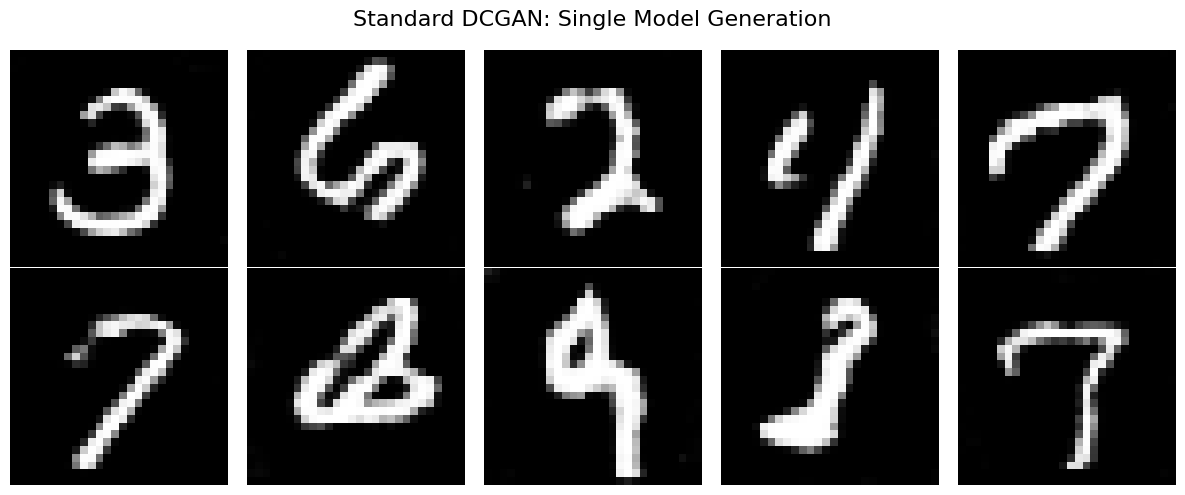

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- 1. Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(mnist_dataset, batch_size=128, shuffle=True)

# --- 2. Architectures (Standard CNN) ---
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x.view(-1, 100, 1, 1))

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),
            nn.Sigmoid() # Standard GAN uses Sigmoid for probability
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

# --- 3. Training Loop ---
gen = Generator().to(device)
disc = Discriminator().to(device)
opt_g = optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_d = optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

epochs = 50 # Standard GANs usually need more epochs for a single model
print("Starting Standard GAN training...")

for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # --- Train Discriminator ---
        opt_d.zero_grad()
        label_real = torch.ones(b_size, 1).to(device)
        label_fake = torch.zeros(b_size, 1).to(device)

        noise = torch.randn(b_size, 100, 1, 1).to(device)
        fake_imgs = gen(noise)

        output_real = disc(real_imgs)
        output_fake = disc(fake_imgs.detach())

        loss_d = (criterion(output_real, label_real) + criterion(output_fake, label_fake)) / 2
        loss_d.backward()
        opt_d.step()

        # --- Train Generator ---
        opt_g.zero_grad()
        output = disc(fake_imgs)
        loss_g = criterion(output, label_real)
        loss_g.backward()
        opt_g.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_d.item():.4f}, Loss G: {loss_g.item():.4f}")

# --- 4. Final Visualization ---
print("Generating Results...")
gen.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Standard DCGAN: Single Model Generation", fontsize=16)

with torch.no_grad():
    noise = torch.randn(10, 100, 1, 1).to(device)
    samples = gen(noise).cpu().squeeze()

for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

USING BOOSTING MODEL AS DISCRIMINATORS

Inizio Training...
Epoch 0 | Loss: 0.2211 | Reward: 0.3154


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Epoch 10 | Loss: 0.0524 | Reward: 0.1947
Epoch 20 | Loss: 0.0201 | Reward: 0.1705


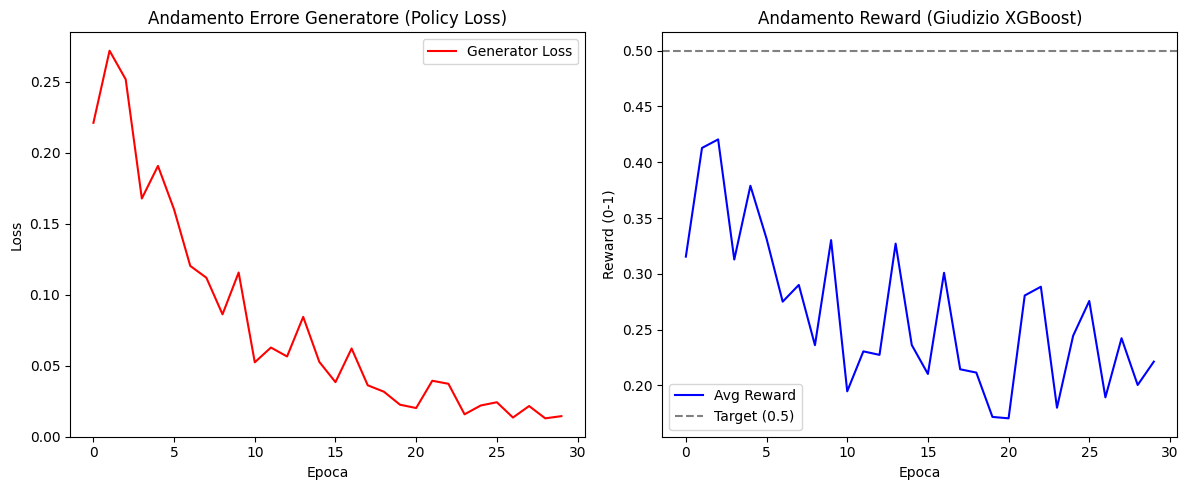

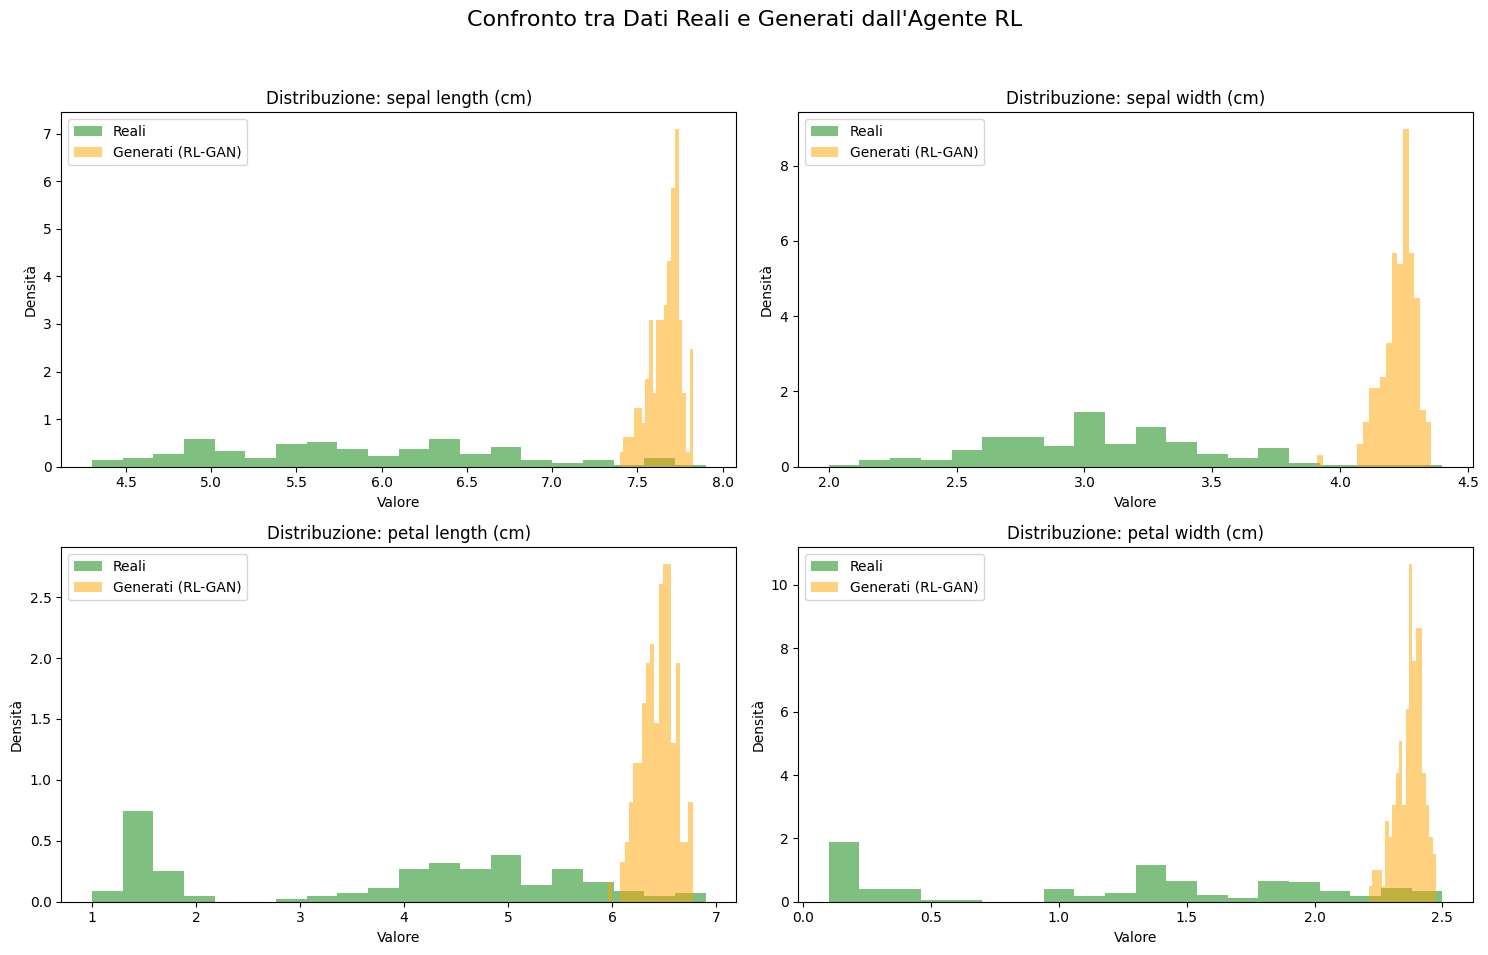

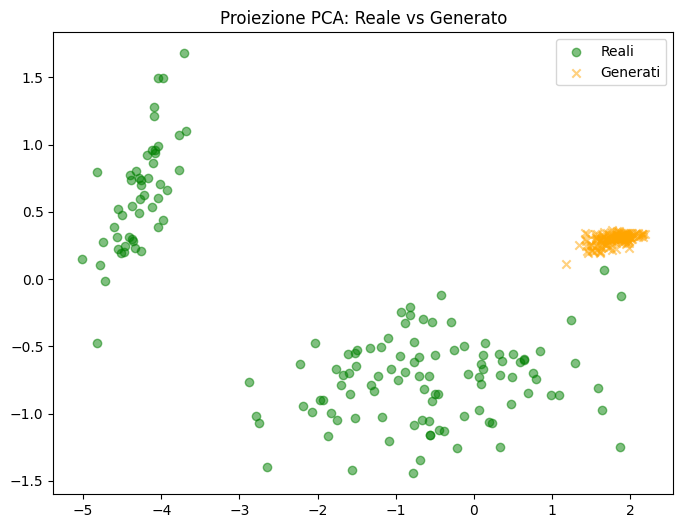

--- CONFRONTO ESEMPI DI DATI (Primi 5 Reali vs Primi 5 Generati) ---
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)     Tipo
          5.100000          3.500000           1.400000          0.200000    REALE
          4.900000          3.000000           1.400000          0.200000    REALE
          4.700000          3.200000           1.300000          0.200000    REALE
          4.600000          3.100000           1.500000          0.200000    REALE
          5.000000          3.600000           1.400000          0.200000    REALE
          7.715970          4.260777           6.521680          2.413846 GENERATO
          7.537083          4.203202           6.234631          2.347868 GENERATO
          7.743654          4.303511           6.569561          2.425642 GENERATO
          7.703240          4.251401           6.436580          2.381997 GENERATO
          7.705634          4.234282           6.468143          2.385165 GENERATO

--- ANALISI STATI

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# --- 1. Setup Dati ---
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data)
n_features = real_data.shape[1]

# --- 2. Modello Generatore ---
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Primo Blocco
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            # Secondo Blocco
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            # Terzo Blocco
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            # Output Layer
            nn.Linear(64, output_dim),
            nn.Sigmoid() # Mantiene l'output nel range [0, 1] dello scaler
        )

    def forward(self, z):
        return self.model(z)

def train_discriminator(gen_model, real_samples, n_noise):
    z = torch.randn(n_noise, 10)
    with torch.no_grad():
        fake_samples = gen_model(z).numpy()
    X = np.vstack([real_samples, fake_samples])
    y = np.hstack([np.ones(len(real_samples)), np.zeros(len(fake_samples))])
    # Modello debole per non "uccidere" il generatore subito
    clf = xgb.XGBClassifier(n_estimators=5, max_depth=3, use_label_encoder=False, eval_metric='logloss')
    clf.fit(X, y)
    return clf

# --- 3. Parametri e Liste per il Plotting ---
latent_dim = 10
gen = Generator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.005)
epochs = 30
batch_size = 32

history = {
    'gen_loss': [],
    'avg_reward': []
}

print("Inizio Training...")

for epoch in range(epochs):
    # Update Discriminatore
    d_model = train_discriminator(gen, real_data, n_noise=batch_size)

    # Update Generatore (RL Step)
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # Calcolo Reward da XGBoost
    rewards = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards, dtype=torch.float32)

    # Calcolo Loss: -Reward * log(probabilità_generata)
    # Usiamo la media della log-probabilità dell'output come proxy per la policy
    log_probs = torch.log(fake_data + 1e-8).mean(dim=1)
    loss = -torch.mean(rewards * log_probs)

    loss.backward()
    optimizer.step()

    # Salvataggio metriche
    history['gen_loss'].append(loss.item())
    history['avg_reward'].append(rewards.mean().item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Reward: {rewards.mean().item():.4f}")

# --- 4. Visualizzazione Risultati ---
plt.figure(figsize=(12, 5))

# Plot della Loss
plt.subplot(1, 2, 1)
plt.plot(history['gen_loss'], color='red', label='Generator Loss')
plt.title('Andamento Errore Generatore (Policy Loss)')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

# Plot del Reward
plt.subplot(1, 2, 2)
plt.plot(history['avg_reward'], color='blue', label='Avg Reward')
plt.title('Andamento Reward (Giudizio XGBoost)')
plt.xlabel('Epoca')
plt.ylabel('Reward (0-1)')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Target (0.5)')
plt.legend()

plt.tight_layout()
plt.show()


# Generiamo un numero di campioni pari al dataset reale per un confronto equo
z_test = torch.randn(len(real_data), latent_dim)
gen.eval() # Modalità valutazione
with torch.no_grad():
    fake_data_scaled = gen(z_test).numpy()

# Riportiamo i dati alla scala originale (de-normalizzazione)
real_data_inv = scaler.inverse_transform(real_data)
fake_data_inv = scaler.inverse_transform(fake_data_scaled)

# Nomi delle colonne del dataset Iris
feature_names = iris.feature_names

# Plot dei confronti
plt.figure(figsize=(15, 10))
for i in range(n_features):
    plt.subplot(2, 2, i+1)

    # Istogramma dati reali
    plt.hist(real_data_inv[:, i], bins=20, alpha=0.5, label='Reali', color='green', density=True)

    # Istogramma dati generati
    plt.hist(fake_data_inv[:, i], bins=20, alpha=0.5, label='Generati (RL-GAN)', color='orange', density=True)

    plt.title(f'Distribuzione: {feature_names[i]}')
    plt.xlabel('Valore')
    plt.ylabel('Densità')
    plt.legend()

plt.suptitle("Confronto tra Dati Reali e Generati dall'Agente RL", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 6. Visualizzazione 2D (PCA) per il "Colpo d'occhio" ---
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
all_data = np.vstack([real_data_inv, fake_data_inv])
pca_res = pca.fit_transform(all_data)

real_pca = pca_res[:len(real_data_inv)]
fake_pca = pca_res[len(real_data_inv):]

plt.figure(figsize=(8, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label='Reali', c='green')
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.5, label='Generati', c='orange', marker='x')
plt.title("Proiezione PCA: Reale vs Generato")
plt.legend()
plt.show()


# 1. Creiamo i DataFrame per i dati reali e generati
df_reali = pd.DataFrame(real_data_inv, columns=feature_names)
df_generati = pd.DataFrame(fake_data_inv, columns=feature_names)

# 2. Aggiungiamo una colonna per distinguerli
df_reali['Tipo'] = 'REALE'
df_generati['Tipo'] = 'GENERATO'

# 3. Selezioniamo un campione casuale di 5 righe per ciascuno
campione_confronto = pd.concat([df_reali.head(5), df_generati.head(5)])

print("--- CONFRONTO ESEMPI DI DATI (Primi 5 Reali vs Primi 5 Generati) ---")
# Usiamo display(campione_confronto) se sei su Jupyter, altrimenti print:
print(campione_confronto.to_string(index=False))

# 4. Statistiche descrittive (per vedere se medie e deviazioni standard matchano)
print("\n--- ANALISI STATISTICA RAPIDA ---")
stats_reali = df_reali.drop('Tipo', axis=1).describe().loc[['mean', 'std', 'min', 'max']]
stats_generati = df_generati.drop('Tipo', axis=1).describe().loc[['mean', 'std', 'min', 'max']]

print("\nMEDIE DATI REALI:")
print(stats_reali.to_string())
print("\nMEDIE DATI GENERATI:")
print(stats_generati.to_string())

Inizio Training...
Epoca   0 | Loss: 0.5632 | Reward: 0.8454 | Diff: 0.3454
Epoca  20 | Loss: 0.3025 | Reward: 0.6501 | Diff: 0.1501
Epoca  40 | Loss: 0.1050 | Reward: 0.2644 | Diff: 0.2356

--- EARLY STOPPING all'epoca 46 ---
Il modello ha raggiunto la massima stabilità possibile rispetto a XGBoost.

--- STATISTICHE DESCRITTIVE A CONFRONTO ---

MEDIA REALE:
 sepal length (cm)    5.843335
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199334
dtype: float32

MEDIA GENERATA:
 sepal length (cm)    6.244574
sepal width (cm)     3.320849
petal length (cm)    4.319980
petal width (cm)     1.427876
dtype: float32


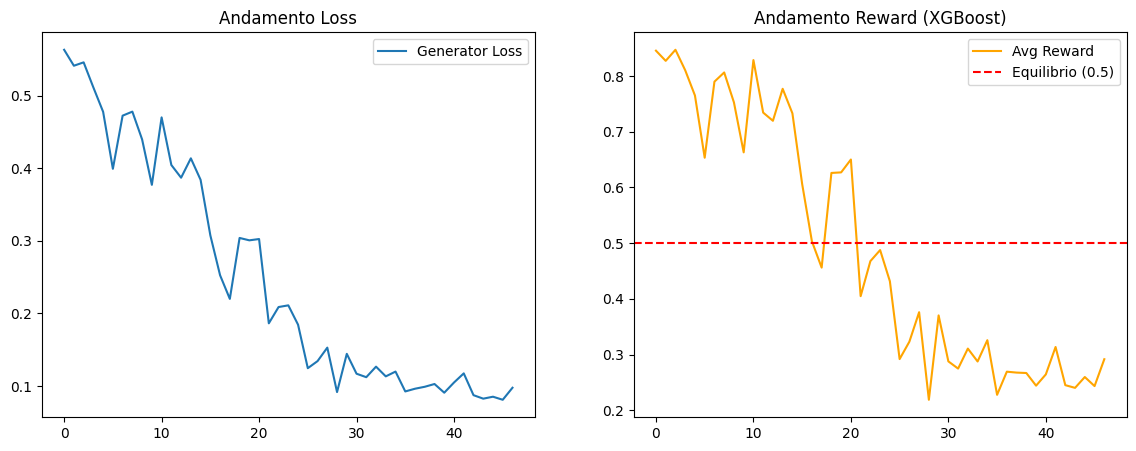


             CONFRONTO STATISTICO: DATI REALI VS GENERATI
                   Mean Reale  Mean Generato  Std Reale  Std Generato  Min Reale  Min Generato  Max Reale  Max Generato
sepal length (cm)    5.843333       6.244575   0.828066      0.082376        4.3      6.068019        7.9      6.424629
sepal width (cm)     3.057333       3.320850   0.435866      0.060292        2.0      3.209398        4.4      3.484954
petal length (cm)    3.758000       4.319980   1.765299      0.150154        1.0      3.990314        6.9      4.737488
petal width (cm)     1.199333       1.427876   0.762238      0.045750        0.1      1.330831        2.5      1.527514

Errore Medio Assoluto (MAE) tra le medie delle feature: 0.3638
>>> Attenzione: C'è ancora una discrepanza significativa tra i dati.


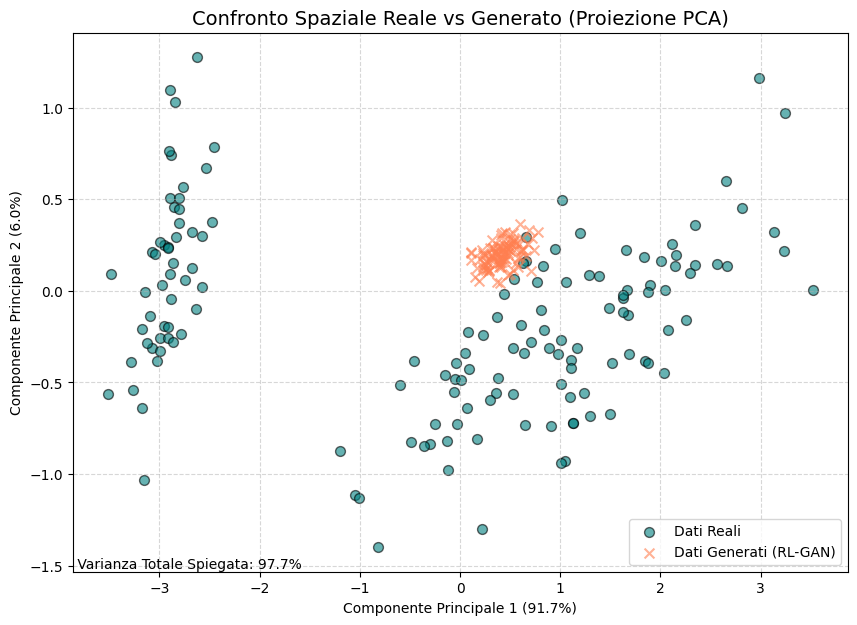

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

# 1. Setup Dati
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data).astype(np.float32)
n_features = real_data.shape[1]

# 2. Generatore "Robust" (BN, Dropout, Residual-like logic)
class RobustGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(RobustGenerator, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2)
        )

        self.output = nn.Sequential(
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.layer1(z)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.output(x)

# 3. Funzione Discriminatore con Label Smoothing
def train_xgb_discriminator(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])
    # Label Smoothing: 0.9 invece di 1 per evitare che XGBoost sia troppo aggressivo
    y = np.hstack([np.ones(len(real_samples)) , np.zeros(len(fake_samples))])

    model = xgb.XGBClassifier(n_estimators=15, max_depth=5, learning_rate=0.1, eval_metric='logloss')
    model.fit(X, y)
    return model

# 4. Training con Early Stopping
latent_dim = 20
batch_size = 64
gen = RobustGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0005, weight_decay=1e-5) # Weight decay per L2 reg

epochs = 500
patience = 30
best_reward_diff = float('inf') # Cerchiamo la differenza minima da 0.5
counter = 0
history = {'loss': [], 'reward': []}

print("Inizio Training...")

for epoch in range(epochs):
    # Training Discriminatore
    d_model = train_xgb_discriminator(gen, real_data, latent_dim, batch_size)

    # Training Generatore (RL)
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # Reward da XGBoost
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)

    # Loss con Entropy Bonus per evitare Mode Collapse
    log_probs = torch.log(fake_data + 1e-8)
    entropy_bonus = fake_data.var(dim=0).mean() # Incoraggia la varietà
    loss = -torch.mean(rewards * log_probs) - (0.05 * entropy_bonus)

    loss.backward()
    optimizer.step()

    # Monitoraggio per Early Stopping
    avg_reward = rewards.mean().item()
    history['loss'].append(loss.item())
    history['reward'].append(avg_reward)

    # Logica Early Stopping: ci fermiamo se il reward è stabilmente vicino a 0.5
    reward_diff = abs(avg_reward - 0.5)
    if reward_diff < best_reward_diff:
        best_reward_diff = reward_diff
        counter = 0
        # Salvataggio del modello migliore (opzionale)
        torch.save(gen.state_dict(), 'best_gen.pth')
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoca {epoch:3d} | Loss: {loss.item():.4f} | Reward: {avg_reward:.4f} | Diff: {reward_diff:.4f}")

    if counter >= patience:
        print(f"\n--- EARLY STOPPING all'epoca {epoch} ---")
        print("Il modello ha raggiunto la massima stabilità possibile rispetto a XGBoost.")
        break

# Carichiamo il peso migliore prima di mostrare i dati
gen.load_state_dict(torch.load('best_gen.pth'))

# 5. Visualizzazione Risultati Finali
gen.eval()
with torch.no_grad():
    fake_final = gen(torch.randn(100, latent_dim)).numpy()
    fake_final = scaler.inverse_transform(fake_final)

real_final = scaler.inverse_transform(real_data)

# Creazione DataFrame per confronto rapido
df_fake = pd.DataFrame(fake_final, columns=iris.feature_names)
df_real = pd.DataFrame(real_final, columns=iris.feature_names)

print("\n--- STATISTICHE DESCRITTIVE A CONFRONTO ---")
print("\nMEDIA REALE:\n", df_real.mean())
print("\nMEDIA GENERATA:\n", df_fake.mean())

# Plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Generator Loss')
plt.title('Andamento Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], color='orange', label='Avg Reward')
plt.axhline(y=0.5, color='red', linestyle='--', label='Equilibrio (0.5)')
plt.title('Andamento Reward (XGBoost)')
plt.legend()
plt.show()


# --- ANALISI STATISTICA DETTAGLIATA ---

# Calcolo delle statistiche descrittive per entrambi i dataset
stats_reali = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_generati = df_fake.describe().loc[['mean', 'std', 'min', 'max']]

# Uniamo i due dataframe per un confronto diretto (Affiancato per metrica)
# Questo rende molto più facile vedere le differenze a colpo d'occhio
confronto_finale = pd.DataFrame(index=df_real.columns)

for metric in ['mean', 'std', 'min', 'max']:
    confronto_finale[f'{metric.capitalize()} Reale'] = stats_reali.loc[metric]
    confronto_finale[f'{metric.capitalize()} Generato'] = stats_generati.loc[metric]

# Formattazione per una stampa elegante
print("\n" + "="*80)
print("             CONFRONTO STATISTICO: DATI REALI VS GENERATI")
print("="*80)
print(confronto_finale.to_string())
print("="*80)

# Calcolo di un punteggio di errore semplice (MAE tra le medie)
mean_error = np.abs(df_real.mean() - df_fake.mean()).mean()
print(f"\nErrore Medio Assoluto (MAE) tra le medie delle feature: {mean_error:.4f}")
if mean_error < 0.1:
    print(">>> Risultato eccellente: Il generatore replica fedelmente le medie reali.")
elif mean_error < 0.3:
    print(">>> Risultato buono: Le distribuzioni sono vicine, ma rifinibili.")
else:
    print(">>> Attenzione: C'è ancora una discrepanza significativa tra i dati.")



from sklearn.decomposition import PCA

# --- VISUALIZZAZIONE 2D TRAMITE PCA ---

# 1. Prepariamo i dati per la PCA
# Uniamo i dati reali e generati per proiettarli nello stesso spazio
X_combined = np.vstack([df_real.values, df_fake.values])

# 2. Applichiamo la PCA riducendo a 2 componenti principali
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_combined)

# 3. Separiamo nuovamente i risultati
pca_real = pca_result[:len(df_real)]
pca_fake = pca_result[len(df_real):]

# 4. Creazione del Plot
plt.figure(figsize=(10, 7))

# Plot dei dati reali
plt.scatter(pca_real[:, 0], pca_real[:, 1],
            color='teal', alpha=0.6, label='Dati Reali',
            edgecolors='k', s=50)

# Plot dei dati generati
plt.scatter(pca_fake[:, 0], pca_fake[:, 1],
            color='coral', alpha=0.6, label='Dati Generati (RL-GAN)',
            marker='x', s=50)

# Calcolo della varianza spiegata per gli assi
var_exp = pca.explained_variance_ratio_ * 100

plt.title('Confronto Spaziale Reale vs Generato (Proiezione PCA)', fontsize=14)
plt.xlabel(f'Componente Principale 1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'Componente Principale 2 ({var_exp[1]:.1f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Aggiungiamo un'annotazione sulla qualità
plt.text(plt.xlim()[0], plt.ylim()[0],
         f" Varianza Totale Spiegata: {sum(var_exp):.1f}%",
         fontsize=10, verticalalignment='bottom')

plt.show()

Inizio Training...
Epoca   0 | Loss: 0.2229 | Reward: 0.2917 | Diff: 0.2083
Epoca  20 | Loss: 0.1589 | Reward: 0.2917 | Diff: 0.2083

--- EARLY STOPPING all'epoca 30 ---
Il modello ha raggiunto la massima stabilità possibile rispetto a XGBoost.

--- STATISTICHE DESCRITTIVE A CONFRONTO ---

MEDIA REALE:
 sepal length (cm)    5.843335
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199334
dtype: float32

MEDIA GENERATA:
 sepal length (cm)    6.052073
sepal width (cm)     3.207393
petal length (cm)    3.870708
petal width (cm)     1.311605
dtype: float32


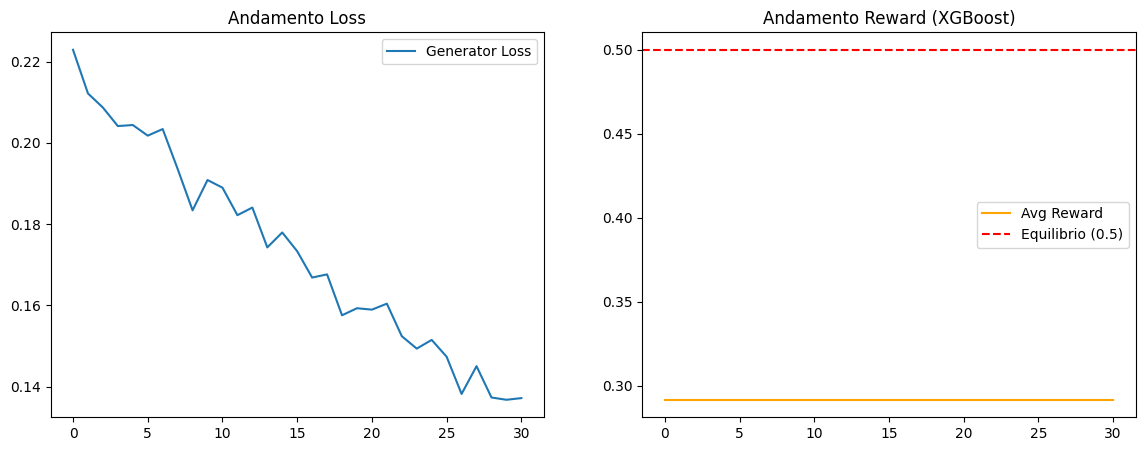


             CONFRONTO STATISTICO: DATI REALI VS GENERATI
                   Mean Reale  Mean Generato  Std Reale  Std Generato  Min Reale  Min Generato  Max Reale  Max Generato
sepal length (cm)    5.843333       6.052073   0.828066      0.045231        4.3      5.925829        7.9      6.144348
sepal width (cm)     3.057333       3.207393   0.435866      0.017186        2.0      3.162576        4.4      3.250300
petal length (cm)    3.758000       3.870708   1.765299      0.054225        1.0      3.717831        6.9      4.001273
petal width (cm)     1.199333       1.311605   0.762238      0.026177        0.1      1.250051        2.5      1.411320

Errore Medio Assoluto (MAE) tra le medie delle feature: 0.1459
>>> Risultato buono: Le distribuzioni sono vicine, ma rifinibili.


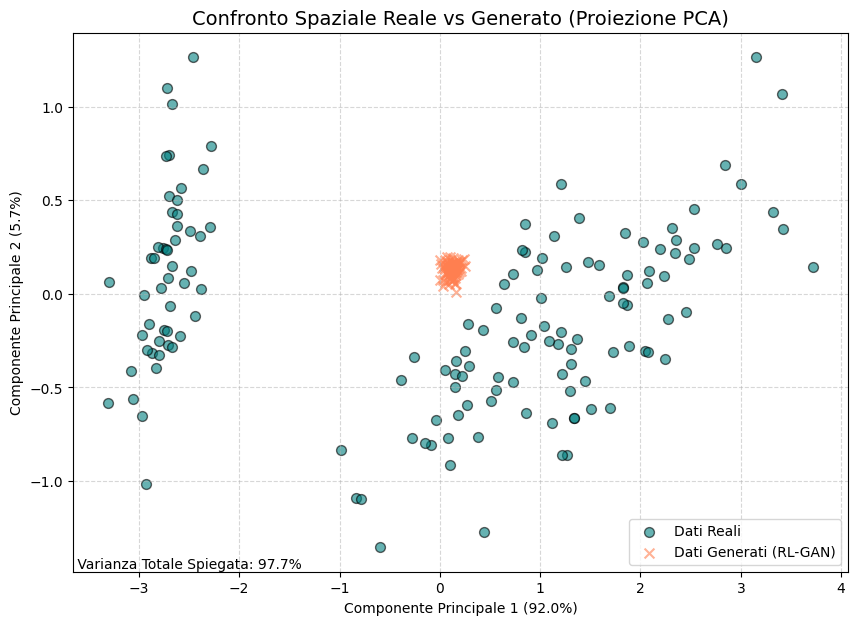

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

# 1. Setup Dati
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data).astype(np.float32)
n_features = real_data.shape[1]

# 2. Generatore "Robust" (BN, Dropout, Residual-like logic)
class RobustGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(RobustGenerator, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer2 = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.layer3 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2)
        )

        self.output = nn.Sequential(
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.layer1(z)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.output(x)

# 3. Funzione Discriminatore con Label Smoothing
def train_xgb_discriminator(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])
    # Label Smoothing: 0.9 invece di 1 per evitare che XGBoost sia troppo aggressivo
    y = np.hstack([np.ones(len(real_samples)) , np.zeros(len(fake_samples))])

    model = xgb.XGBClassifier(n_estimators=15, max_depth=5, learning_rate=0.1, eval_metric='logloss')
    model.fit(X, y)
    return model

# 4. Training con Early Stopping
latent_dim = 20
batch_size = 64
gen = RobustGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0005, weight_decay=1e-5) # Weight decay per L2 reg

epochs = 500
patience = 30
best_reward_diff = float('inf') # Cerchiamo la differenza minima da 0.5
counter = 0
history = {'loss': [], 'reward': []}

print("Inizio Training...")

# --- CODICE AGGIORNATO: LOSS CON ENTROPY BONUS ---

for epoch in range(epochs):
    # ... (addestramento XGBoost come prima) ...

    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # ... (calcolo reward da XGBoost come prima) ...

    # --- INIZIO MODIFICA: CALCOLO ENTROPIA ---
    # Calcoliamo la varianza di ogni feature all'interno del batch attuale.
    # .var(dim=0) calcola la varianza lungo la colonna (feature).
    batch_variance_per_feature = fake_data.var(dim=0)

    # La media delle varianze di tutte le feature è la nostra "misura di varietà".
    # Vogliamo che questo numero sia ALTO.
    entropy_bonus = batch_variance_per_feature.mean()

    # Parametro beta: definisce quanto "peso" dare alla varietà rispetto al reward.
    # Parti da 0.1 e aumenta se c'è ancora mode collapse.
    beta = 0.1

    # --- NUOVA LOSS FORMULA ---
    # Loss standard pesata dal reward + (beta * penalità di entropia)
    # Nota: Poiché l'ottimizzatore minimizza la loss, e noi vogliamo MASSIMIZZARE
    # l'entropia, dobbiamo SOTTRARRE l'entropy bonus dalla loss.
    log_probs = torch.log(fake_data + 1e-8)
    loss = -torch.mean(rewards * log_probs) - (beta * entropy_bonus)
    # -----------------------------------------------

    loss.backward()
    optimizer.step()

    # ... (log e plot come prima) ...

    # Monitoraggio per Early Stopping
    avg_reward = rewards.mean().item()
    history['loss'].append(loss.item())
    history['reward'].append(avg_reward)

    # Logica Early Stopping: ci fermiamo se il reward è stabilmente vicino a 0.5
    reward_diff = abs(avg_reward - 0.5)
    if reward_diff < best_reward_diff:
        best_reward_diff = reward_diff
        counter = 0
        # Salvataggio del modello migliore (opzionale)
        torch.save(gen.state_dict(), 'best_gen.pth')
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoca {epoch:3d} | Loss: {loss.item():.4f} | Reward: {avg_reward:.4f} | Diff: {reward_diff:.4f}")

    if counter >= patience:
        print(f"\n--- EARLY STOPPING all'epoca {epoch} ---")
        print("Il modello ha raggiunto la massima stabilità possibile rispetto a XGBoost.")
        break

# Carichiamo il peso migliore prima di mostrare i dati
gen.load_state_dict(torch.load('best_gen.pth'))

# 5. Visualizzazione Risultati Finali
gen.eval()
with torch.no_grad():
    fake_final = gen(torch.randn(100, latent_dim)).numpy()
    fake_final = scaler.inverse_transform(fake_final)

real_final = scaler.inverse_transform(real_data)

# Creazione DataFrame per confronto rapido
df_fake = pd.DataFrame(fake_final, columns=iris.feature_names)
df_real = pd.DataFrame(real_final, columns=iris.feature_names)

print("\n--- STATISTICHE DESCRITTIVE A CONFRONTO ---")
print("\nMEDIA REALE:\n", df_real.mean())
print("\nMEDIA GENERATA:\n", df_fake.mean())

# Plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Generator Loss')
plt.title('Andamento Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], color='orange', label='Avg Reward')
plt.axhline(y=0.5, color='red', linestyle='--', label='Equilibrio (0.5)')
plt.title('Andamento Reward (XGBoost)')
plt.legend()
plt.show()


# --- ANALISI STATISTICA DETTAGLIATA ---

# Calcolo delle statistiche descrittive per entrambi i dataset
stats_reali = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_generati = df_fake.describe().loc[['mean', 'std', 'min', 'max']]

# Uniamo i due dataframe per un confronto diretto (Affiancato per metrica)
# Questo rende molto più facile vedere le differenze a colpo d'occhio
confronto_finale = pd.DataFrame(index=df_real.columns)

for metric in ['mean', 'std', 'min', 'max']:
    confronto_finale[f'{metric.capitalize()} Reale'] = stats_reali.loc[metric]
    confronto_finale[f'{metric.capitalize()} Generato'] = stats_generati.loc[metric]

# Formattazione per una stampa elegante
print("\n" + "="*80)
print("             CONFRONTO STATISTICO: DATI REALI VS GENERATI")
print("="*80)
print(confronto_finale.to_string())
print("="*80)

# Calcolo di un punteggio di errore semplice (MAE tra le medie)
mean_error = np.abs(df_real.mean() - df_fake.mean()).mean()
print(f"\nErrore Medio Assoluto (MAE) tra le medie delle feature: {mean_error:.4f}")
if mean_error < 0.1:
    print(">>> Risultato eccellente: Il generatore replica fedelmente le medie reali.")
elif mean_error < 0.3:
    print(">>> Risultato buono: Le distribuzioni sono vicine, ma rifinibili.")
else:
    print(">>> Attenzione: C'è ancora una discrepanza significativa tra i dati.")



from sklearn.decomposition import PCA

# --- VISUALIZZAZIONE 2D TRAMITE PCA ---

# 1. Prepariamo i dati per la PCA
# Uniamo i dati reali e generati per proiettarli nello stesso spazio
X_combined = np.vstack([df_real.values, df_fake.values])

# 2. Applichiamo la PCA riducendo a 2 componenti principali
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_combined)

# 3. Separiamo nuovamente i risultati
pca_real = pca_result[:len(df_real)]
pca_fake = pca_result[len(df_real):]

# 4. Creazione del Plot
plt.figure(figsize=(10, 7))

# Plot dei dati reali
plt.scatter(pca_real[:, 0], pca_real[:, 1],
            color='teal', alpha=0.6, label='Dati Reali',
            edgecolors='k', s=50)

# Plot dei dati generati
plt.scatter(pca_fake[:, 0], pca_fake[:, 1],
            color='coral', alpha=0.6, label='Dati Generati (RL-GAN)',
            marker='x', s=50)

# Calcolo della varianza spiegata per gli assi
var_exp = pca.explained_variance_ratio_ * 100

plt.title('Confronto Spaziale Reale vs Generato (Proiezione PCA)', fontsize=14)
plt.xlabel(f'Componente Principale 1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'Componente Principale 2 ({var_exp[1]:.1f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Aggiungiamo un'annotazione sulla qualità
plt.text(plt.xlim()[0], plt.ylim()[0],
         f" Varianza Totale Spiegata: {sum(var_exp):.1f}%",
         fontsize=10, verticalalignment='bottom')

plt.show()

Inizio Training...
Epoca   0 | Loss: -5114.5254 | Reward: 0.2917 | Diff: 0.2083
Epoca  20 | Loss: -12377.9805 | Reward: 0.2917 | Diff: 0.2083

--- EARLY STOPPING all'epoca 30 ---
Il modello ha raggiunto la massima stabilità possibile rispetto a XGBoost.

--- STATISTICHE DESCRITTIVE A CONFRONTO ---

MEDIA REALE:
 sepal length (cm)    5.843335
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199334
dtype: float32

MEDIA GENERATA:
 sepal length (cm)    6.080407
sepal width (cm)     3.176765
petal length (cm)    4.057127
petal width (cm)     1.274177
dtype: float32


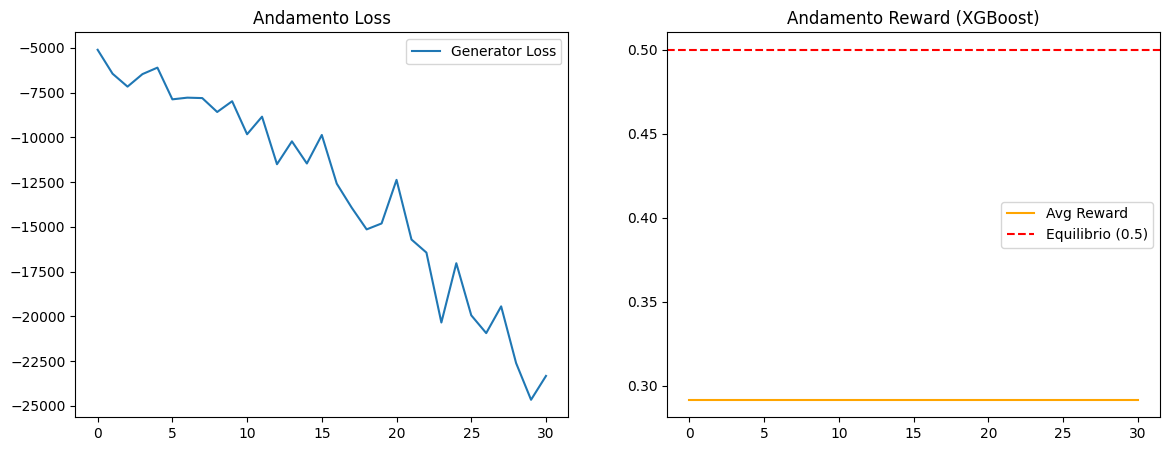


             CONFRONTO STATISTICO: DATI REALI VS GENERATI
                   Mean Reale  Mean Generato  Std Reale  Std Generato  Min Reale  Min Generato  Max Reale  Max Generato
sepal length (cm)    5.843333       6.080408   0.828066      0.058477        4.3      5.923406        7.9      6.205081
sepal width (cm)     3.057333       3.176764   0.435866      0.042346        2.0      3.043061        4.4      3.266923
petal length (cm)    3.758000       4.057127   1.765299      0.090604        1.0      3.861239        6.9      4.320888
petal width (cm)     1.199333       1.274177   0.762238      0.039623        0.1      1.180189        2.5      1.360755

Errore Medio Assoluto (MAE) tra le medie delle feature: 0.1826
>>> Risultato buono: Le distribuzioni sono vicine, ma rifinibili.


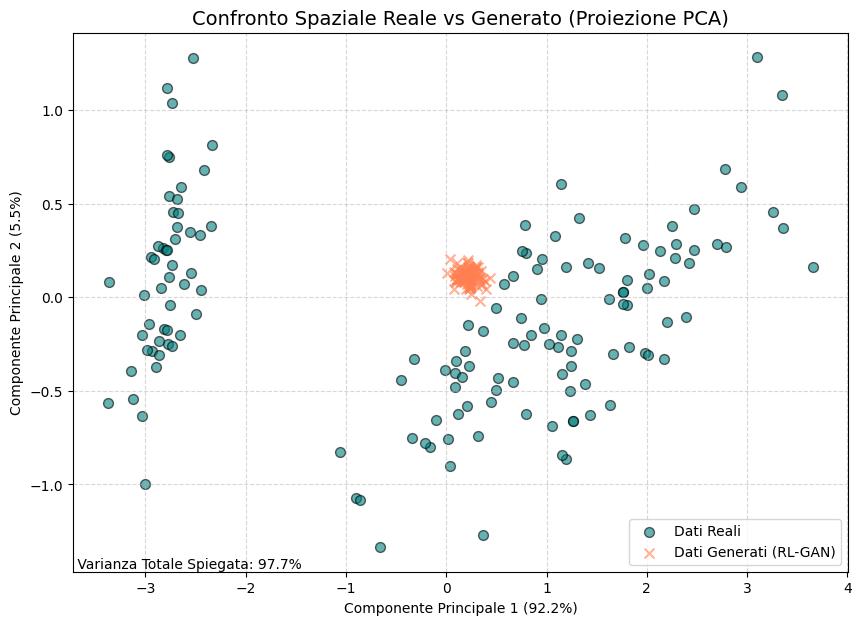

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

# 1. Setup Dati
iris = load_iris()
scaler = MinMaxScaler()
real_data = scaler.fit_transform(iris.data).astype(np.float32)
n_features = real_data.shape[1]

# 2. Generatore "Robust" (BN, Dropout, Residual-like logic)
class VariedGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(VariedGenerator, self).__init__()

        # Layer 1
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(0.3)

        # Layer 2
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)

        # Output
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, z):
        # Layer 1
        x = torch.relu(self.bn1(self.fc1(z)))
        x = self.drop1(x)

        # --- INIZIO MODIFICA: NOISE INJECTION INTERMEDIO ---
        # Aggiungiamo un rumore gaussiano proporzionale all'intensità dell'attivazione
        # Solo durante il training
        if self.training:
            noise = torch.randn_like(x) * 0.1 # 5% di intensità di rumore
            x = x + noise
        # ---------------------------------------------------

        # Layer 2
        x = torch.relu(self.bn2(self.fc2(x)))

        # Output
        return torch.sigmoid(self.fc3(x))

# 3. Funzione Discriminatore con Label Smoothing
def train_xgb_discriminator(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])
    # Label Smoothing: 0.9 invece di 1 per evitare che XGBoost sia troppo aggressivo
    y = np.hstack([np.ones(len(real_samples)) , np.zeros(len(fake_samples))])

    model = xgb.XGBClassifier(n_estimators=15, max_depth=5, learning_rate=0.1, eval_metric='logloss')
    model.fit(X, y)
    return model

# 4. Training con Early Stopping
latent_dim = 20
batch_size = 64
gen = VariedGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0005, weight_decay=1e-5) # Weight decay per L2 reg

epochs = 500
patience = 30
best_reward_diff = float('inf') # Cerchiamo la differenza minima da 0.5
counter = 0
history = {'loss': [], 'reward': []}

print("Inizio Training...")

# --- CODICE AGGIORNATO: LOSS CON ENTROPY BONUS ---

for epoch in range(epochs):
    # ... (addestramento XGBoost come prima) ...

    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # ... (calcolo reward da XGBoost come prima) ...

    # --- INIZIO MODIFICA: CALCOLO ENTROPIA ---
    # Calcoliamo la varianza di ogni feature all'interno del batch attuale.
    # .var(dim=0) calcola la varianza lungo la colonna (feature).
    batch_variance_per_feature = fake_data.var(dim=0)

    # La media delle varianze di tutte le feature è la nostra "misura di varietà".
    # Vogliamo che questo numero sia ALTO.
    entropy_bonus = batch_variance_per_feature.mean()

    # Parametro beta: definisce quanto "peso" dare alla varietà rispetto al reward.
    # Parti da 0.1 e aumenta se c'è ancora mode collapse.
    beta = 1000000

    # --- NUOVA LOSS FORMULA ---
    # Loss standard pesata dal reward + (beta * penalità di entropia)
    # Nota: Poiché l'ottimizzatore minimizza la loss, e noi vogliamo MASSIMIZZARE
    # l'entropia, dobbiamo SOTTRARRE l'entropy bonus dalla loss.
    log_probs = torch.log(fake_data + 1e-8)
    loss = -torch.mean(rewards * log_probs) - (beta * entropy_bonus)
    # -----------------------------------------------

    loss.backward()
    optimizer.step()

    # ... (log e plot come prima) ...

    # Monitoraggio per Early Stopping
    avg_reward = rewards.mean().item()
    history['loss'].append(loss.item())
    history['reward'].append(avg_reward)

    # Logica Early Stopping: ci fermiamo se il reward è stabilmente vicino a 0.5
    reward_diff = abs(avg_reward - 0.5)
    if reward_diff < best_reward_diff:
        best_reward_diff = reward_diff
        counter = 0
        # Salvataggio del modello migliore (opzionale)
        torch.save(gen.state_dict(), 'best_gen.pth')
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoca {epoch:3d} | Loss: {loss.item():.4f} | Reward: {avg_reward:.4f} | Diff: {reward_diff:.4f}")

    if counter >= patience:
        print(f"\n--- EARLY STOPPING all'epoca {epoch} ---")
        print("Il modello ha raggiunto la massima stabilità possibile rispetto a XGBoost.")
        break

# Carichiamo il peso migliore prima di mostrare i dati
gen.load_state_dict(torch.load('best_gen.pth'))

# 5. Visualizzazione Risultati Finali
gen.eval()
with torch.no_grad():
    fake_final = gen(torch.randn(100, latent_dim)).numpy()
    fake_final = scaler.inverse_transform(fake_final)

real_final = scaler.inverse_transform(real_data)

# Creazione DataFrame per confronto rapido
df_fake = pd.DataFrame(fake_final, columns=iris.feature_names)
df_real = pd.DataFrame(real_final, columns=iris.feature_names)

print("\n--- STATISTICHE DESCRITTIVE A CONFRONTO ---")
print("\nMEDIA REALE:\n", df_real.mean())
print("\nMEDIA GENERATA:\n", df_fake.mean())

# Plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Generator Loss')
plt.title('Andamento Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], color='orange', label='Avg Reward')
plt.axhline(y=0.5, color='red', linestyle='--', label='Equilibrio (0.5)')
plt.title('Andamento Reward (XGBoost)')
plt.legend()
plt.show()


# --- ANALISI STATISTICA DETTAGLIATA ---

# Calcolo delle statistiche descrittive per entrambi i dataset
stats_reali = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_generati = df_fake.describe().loc[['mean', 'std', 'min', 'max']]

# Uniamo i due dataframe per un confronto diretto (Affiancato per metrica)
# Questo rende molto più facile vedere le differenze a colpo d'occhio
confronto_finale = pd.DataFrame(index=df_real.columns)

for metric in ['mean', 'std', 'min', 'max']:
    confronto_finale[f'{metric.capitalize()} Reale'] = stats_reali.loc[metric]
    confronto_finale[f'{metric.capitalize()} Generato'] = stats_generati.loc[metric]

# Formattazione per una stampa elegante
print("\n" + "="*80)
print("             CONFRONTO STATISTICO: DATI REALI VS GENERATI")
print("="*80)
print(confronto_finale.to_string())
print("="*80)

# Calcolo di un punteggio di errore semplice (MAE tra le medie)
mean_error = np.abs(df_real.mean() - df_fake.mean()).mean()
print(f"\nErrore Medio Assoluto (MAE) tra le medie delle feature: {mean_error:.4f}")
if mean_error < 0.1:
    print(">>> Risultato eccellente: Il generatore replica fedelmente le medie reali.")
elif mean_error < 0.3:
    print(">>> Risultato buono: Le distribuzioni sono vicine, ma rifinibili.")
else:
    print(">>> Attenzione: C'è ancora una discrepanza significativa tra i dati.")



from sklearn.decomposition import PCA

# --- VISUALIZZAZIONE 2D TRAMITE PCA ---

# 1. Prepariamo i dati per la PCA
# Uniamo i dati reali e generati per proiettarli nello stesso spazio
X_combined = np.vstack([df_real.values, df_fake.values])

# 2. Applichiamo la PCA riducendo a 2 componenti principali
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_combined)

# 3. Separiamo nuovamente i risultati
pca_real = pca_result[:len(df_real)]
pca_fake = pca_result[len(df_real):]

# 4. Creazione del Plot
plt.figure(figsize=(10, 7))

# Plot dei dati reali
plt.scatter(pca_real[:, 0], pca_real[:, 1],
            color='teal', alpha=0.6, label='Dati Reali',
            edgecolors='k', s=50)

# Plot dei dati generati
plt.scatter(pca_fake[:, 0], pca_fake[:, 1],
            color='coral', alpha=0.6, label='Dati Generati (RL-GAN)',
            marker='x', s=50)

# Calcolo della varianza spiegata per gli assi
var_exp = pca.explained_variance_ratio_ * 100

plt.title('Confronto Spaziale Reale vs Generato (Proiezione PCA)', fontsize=14)
plt.xlabel(f'Componente Principale 1 ({var_exp[0]:.1f}%)')
plt.ylabel(f'Componente Principale 2 ({var_exp[1]:.1f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Aggiungiamo un'annotazione sulla qualità
plt.text(plt.xlim()[0], plt.ylim()[0],
         f" Varianza Totale Spiegata: {sum(var_exp):.1f}%",
         fontsize=10, verticalalignment='bottom')

plt.show()

Inizio addestramento con forzatura della variabilità...
Epoch   0 | Reward Med: 0.708 | Moment Loss: 0.0546
Epoch  50 | Reward Med: 0.682 | Moment Loss: 0.0007
Epoch 100 | Reward Med: 0.679 | Moment Loss: 0.0156
Epoch 150 | Reward Med: 0.636 | Moment Loss: 0.0454
Epoch 200 | Reward Med: 0.641 | Moment Loss: 0.0435
Epoch 250 | Reward Med: 0.637 | Moment Loss: 0.0440

============================== STATISTICHE ==============================
               sepal length (cm)  sepal width (cm)  petal length (cm)  \
REALE    mean           5.843333          3.057333           3.758000   
         std            0.828066          0.435866           1.765299   
         min            4.300000          2.000000           1.000000   
         max            7.900000          4.400000           6.900000   
GENERATO mean           6.123969          2.722566           4.041946   
         std            1.765738          0.700547           2.910221   
         min            4.300000          2.00

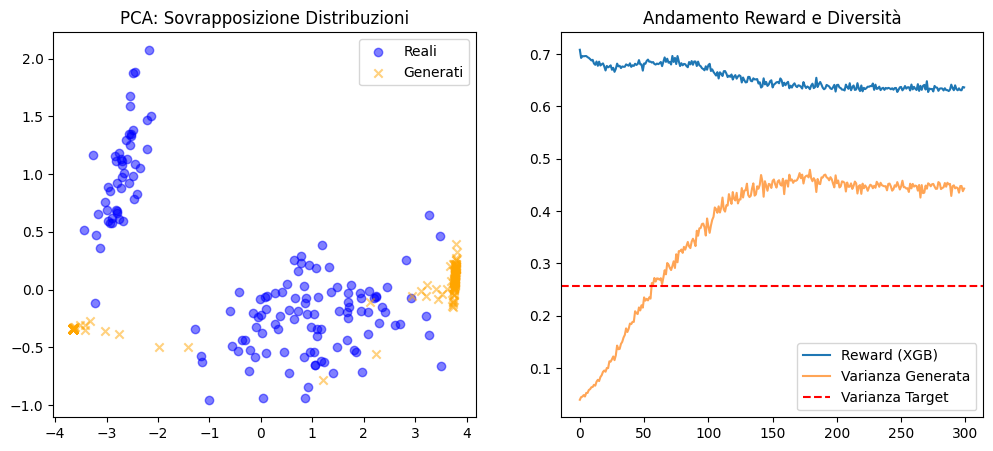

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# --- 1. SETUP DATI ---
iris = load_iris()
scaler = MinMaxScaler()
real_data_raw = iris.data.astype(np.float32)
real_data_scaled = scaler.fit_transform(real_data_raw)
n_features = real_data_scaled.shape[1]
feature_names = iris.feature_names

# Calcoliamo i momenti statistici reali (Target per il Generatore)
target_mean = torch.tensor(real_data_scaled.mean(axis=0))
target_std = torch.tensor(real_data_scaled.std(axis=0))

# --- 2. GENERATORE PROFONDO E DINAMICO ---
class UltimateGenerator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(UltimateGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        # Noise Injection all'input per aumentare la stocasticità
        if self.training:
            z = z + torch.randn_like(z) * 0.1
        return self.net(z)

# --- 3. FUNZIONE TRAINING DISCRIMINATORE (XGBOOST DEBOLE) ---
def train_weak_xgb(gen, real_samples, latent_dim, batch_size):
    gen.eval()
    with torch.no_grad():
        z = torch.randn(batch_size, latent_dim)
        fake_samples = gen(z).numpy()
    gen.train()

    X = np.vstack([real_samples, fake_samples])
    # Label smoothing (0.9 invece di 1)
    y = np.hstack([np.ones(len(real_samples)), np.zeros(len(fake_samples))])

    # Parametri "Miopi": pochi alberi e poca profondità per forzare la vaghezza
    model = xgb.XGBClassifier(
        n_estimators=3,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.6,
        eval_metric='logloss'
    )
    model.fit(X, y)
    return model

# --- 4. TRAINING LOOP CON REWARD NORMALIZATION ---
latent_dim = 24
batch_size = 64
gen = UltimateGenerator(latent_dim, n_features)
optimizer = optim.Adam(gen.parameters(), lr=0.0003)

epochs = 300
history = {'loss': [], 'reward': [], 'diversity': []}

print("Inizio addestramento con forzatura della variabilità...")

for epoch in range(epochs):
    # A. Fase Discriminatore
    d_model = train_weak_xgb(gen, real_data_scaled, latent_dim, batch_size)

    # B. Fase Generatore
    optimizer.zero_grad()
    z = torch.randn(batch_size, latent_dim)
    fake_data = gen(z)

    # 1. Calcolo Reward Grezzo
    rewards_np = d_model.predict_proba(fake_data.detach().numpy())[:, 1]
    rewards = torch.tensor(rewards_np, dtype=torch.float32).unsqueeze(1)

    # 2. REWARD NORMALIZATION (Z-Score)
    # Questo obbliga il generatore a vedere differenze anche tra dati ottimi
    if rewards.std() > 1e-4:
        norm_rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
    else:
        norm_rewards = rewards - 0.5 # Offset se sono tutti uguali

    # 3. MOMENT MATCHING LOSS (Obbliga la distribuzione simile)
    fake_mean = fake_data.mean(dim=0)
    fake_std = fake_data.std(dim=0)

    # Penalità se media e deviazione standard del batch sono diverse dal reale
    moment_loss = torch.mean((fake_mean - target_mean)**2) + torch.mean((fake_std - target_std)**2)

    # 4. POLICY GRADIENT LOSS
    log_probs = torch.log(fake_data + 1e-8)
    # Uniamo Reward Normalizzato e Moment Matching (Peso 5.0 per forzare la mano)
    policy_loss = -torch.mean(norm_rewards * log_probs)
    total_loss = policy_loss + (10.0 * moment_loss)

    total_loss.backward()
    optimizer.step()

    # Log
    history['loss'].append(total_loss.item())
    history['reward'].append(rewards.mean().item())
    history['diversity'].append(fake_std.mean().item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Reward Med: {rewards.mean().item():.3f} | Moment Loss: {moment_loss.item():.4f}")

# --- 5. VALUTAZIONE FINALE ---
gen.eval()
with torch.no_grad():
    final_z = torch.randn(200, latent_dim)
    fake_final_scaled = gen(final_z).numpy()
    fake_final = scaler.inverse_transform(fake_final_scaled)

df_real = pd.DataFrame(real_data_raw, columns=feature_names)
df_fake = pd.DataFrame(fake_final, columns=feature_names)

# A. Tabella Statistica
stats_reali = df_real.describe().loc[['mean', 'std', 'min', 'max']]
stats_fake = df_fake.describe().loc[['mean', 'std', 'min', 'max']]
confronto = pd.concat([stats_reali, stats_fake], axis=0, keys=['REALE', 'GENERATO'])

print("\n" + "="*30 + " STATISTICHE " + "="*30)
print(confronto)

# B. Plot PCA
pca = PCA(n_components=2)
all_pca = pca.fit_transform(np.vstack([real_data_raw, fake_final]))
real_pca = all_pca[:len(real_data_raw)]
fake_pca = all_pca[len(real_data_raw):]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, label='Reali', c='blue')
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.5, label='Generati', c='orange', marker='x')
plt.title("PCA: Sovrapposizione Distribuzioni")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['reward'], label='Reward (XGB)')
plt.plot(history['diversity'], label='Varianza Generata', alpha=0.7)
plt.axhline(y=target_std.mean().item(), color='red', linestyle='--', label='Varianza Target')
plt.title("Andamento Reward e Diversità")
plt.legend()
plt.show()